In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
PYFILES = PROJECT_ROOT / "pyfiles"
if str(PYFILES) not in sys.path:
    sys.path.insert(0, str(PYFILES))

In [2]:
import pandas as pd


RESULTS = Path("..").resolve() / "resultsv2" / "test_runs"

dfs = [pd.read_json(f) for f in sorted(RESULTS.glob("*.json"))]
df = pd.concat(dfs, ignore_index=True)

pd.set_option("display.max_columns", 200)
df

,cfg.backend,cfg.model_precision,input_bits_trained,top1_mean,top1_std,top5_mean,top5_std,infer_ms_mean,infer_ms_std,throughput_mean,qat_precision,input_bits,top1,top5,lat_ms,throughput,method,lat_std
0,pytorch,fp16,1.0,69.551,0.475,89.477,0.126,3.065,0.058,326.331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pytorch,fp16,2.0,76.888,0.425,93.139,0.053,3.075,0.046,325.244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pytorch,fp16,4.0,78.330,0.369,93.642,0.101,3.087,0.029,323.959,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pytorch,fp16,8.0,77.975,0.101,93.581,0.237,3.048,0.050,328.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pytorch,fp32,1.0,69.551,0.466,89.470,0.129,2.980,0.013,335.550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,pytorch,fp32,2.0,76.861,0.413,93.139,0.053,2.984,0.034,335.128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,pytorch,fp32,4.0,78.337,0.332,93.655,0.103,3.082,0.019,324.479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,pytorch,fp32,8.0,77.988,0.132,93.581,0.232,3.043,0.065,328.733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,tensorrt,fp16,8.0,77.988,0.112,93.588,0.229,0.487,0.027,2058.048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,tensorrt,fp16,4.0,78.343,0.360,93.635,0.111,0.472,0.005,2120.904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
pt_trt = df[df["cfg.backend"].notna()][
    ["cfg.backend", "cfg.model_precision", "input_bits_trained",
     "top1_mean", "top1_std", "top5_mean", "top5_std",
     "infer_ms_mean", "infer_ms_std"]
].rename(columns={
    "cfg.backend": "backend",
    "cfg.model_precision": "precision",
    "input_bits_trained": "input_bits",
})

qat = df[df["qat_precision"].notna()][
    ["qat_precision", "input_bits", "top1", "top5", "lat_ms"]
].rename(columns={
    "qat_precision": "precision",
    "top1": "top1_mean",
    "top5": "top5_mean",
    "lat_ms": "infer_ms_mean",
})
qat["backend"] = "pytorch"

qat_trt = df[df["method"] == "qat_int8_trt"][
    ["input_bits", "top1", "top5", "lat_ms"]
].rename(columns={
    "top1": "top1_mean",
    "top5": "top5_mean",
    "lat_ms": "infer_ms_mean",
})
qat_trt["backend"] = "tensorrt"
qat_trt["precision"] = "qat_int8"

combined = pd.concat([pt_trt, qat, qat_trt], ignore_index=True).sort_values(
    ["backend", "precision", "input_bits"], ascending=[True, True, False]
).reset_index(drop=True)

combined

,backend,precision,input_bits,top1_mean,top1_std,top5_mean,top5_std,infer_ms_mean,infer_ms_std
0,pytorch,fp16,8.0,77.975000,0.101,93.581000,0.237,3.048000,0.050
1,pytorch,fp16,4.0,78.330000,0.369,93.642000,0.101,3.087000,0.029
2,pytorch,fp16,2.0,76.888000,0.425,93.139000,0.053,3.075000,0.046
3,pytorch,fp16,1.0,69.551000,0.475,89.477000,0.126,3.065000,0.058
4,pytorch,fp32,8.0,77.988000,0.132,93.581000,0.232,3.043000,0.065
5,pytorch,fp32,4.0,78.337000,0.332,93.655000,0.103,3.082000,0.019
6,pytorch,fp32,2.0,76.861000,0.413,93.139000,0.053,2.984000,0.034
7,pytorch,fp32,1.0,69.551000,0.466,89.470000,0.129,2.980000,0.013
8,pytorch,qat_int4,8.0,77.102616,NaN,93.098592,NaN,9.398007,NaN
9,pytorch,qat_int4,4.0,77.444668,NaN,93.118712,NaN,9.394407,NaN


In [4]:
import json
import numpy as np

BENCH_DIR = PROJECT_ROOT / "resultsv2" / "latency_bench"

bench_stds = {}
for bench_file in sorted(BENCH_DIR.glob("*.json")):
    with open(bench_file) as f:
        bench = json.load(f)
    backend = bench_file.stem.split("_")[0]
    bench_stds[backend] = np.std(bench["latencies_ms"], ddof=1)

print("Bench stds:", {k: f"{v:.3f}" for k, v in bench_stds.items()})

combined["infer_ms_std"] = combined.apply(
    lambda r: np.nan if r["precision"].startswith("qat") else bench_stds.get(r["backend"], 0),
    axis=1,
)

combined

Bench stds: {'pytorch': '1.244', 'tensorrt': '0.276'}


,backend,precision,input_bits,top1_mean,top1_std,top5_mean,top5_std,infer_ms_mean,infer_ms_std
0,pytorch,fp16,8.0,77.975000,0.101,93.581000,0.237,3.048000,1.243958
1,pytorch,fp16,4.0,78.330000,0.369,93.642000,0.101,3.087000,1.243958
2,pytorch,fp16,2.0,76.888000,0.425,93.139000,0.053,3.075000,1.243958
3,pytorch,fp16,1.0,69.551000,0.475,89.477000,0.126,3.065000,1.243958
4,pytorch,fp32,8.0,77.988000,0.132,93.581000,0.232,3.043000,1.243958
5,pytorch,fp32,4.0,78.337000,0.332,93.655000,0.103,3.082000,1.243958
6,pytorch,fp32,2.0,76.861000,0.413,93.139000,0.053,2.984000,1.243958
7,pytorch,fp32,1.0,69.551000,0.466,89.470000,0.129,2.980000,1.243958
8,pytorch,qat_int4,8.0,77.102616,NaN,93.098592,NaN,9.398007,NaN
9,pytorch,qat_int4,4.0,77.444668,NaN,93.118712,NaN,9.394407,NaN


In [5]:
out_path = PROJECT_ROOT / "resultsv2" / "test_final_results.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
combined.fillna(0).to_json(out_path, orient="records", indent=2)
print(f"Saved to {out_path}")

Saved to /home/pf4636/code/resnet/quantized_resnets/resultsv2/test_final_results.json


## Plots

In [6]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"] = 150

PROJECT_ROOT = Path("..").resolve()
combined = pd.read_json(PROJECT_ROOT / "resultsv2" / "test_final_results.json")

COLS = 2
eb_kw = dict(capsize=3, capthick=0.8, elinewidth=0.8, linewidth=0)

BIT_PALETTE = {
    1: "#002B45",
    2: "#009681",
    4: "#239ED7",
    8: "#8DB23E",
}

PREC_PALETTE = {
    "fp32": "#002B45",
    "fp16": "#239ED7",
    "fp8":  "#009681",
    "int8": "#8DB23E",
    "int4": "#0E4B75",
    "qat_int8": "#D62728",
    "qat_int4": "#FF7F0E",
}

QAT_PALETTE = {
    "qat_int8": "#009681", "qat_int4": "#FF7F0E",
    "int8": "#0E4B75", "int4": "#002B45",
}

def make_figure(title, n):
    nrows = math.ceil(n / COLS)
    fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 3.8 * nrows),
                             constrained_layout=True, squeeze=False)
    fig.suptitle(title, fontsize=12, fontweight="normal",
                 x=0.5, ha="center", y=1.04)
    fig.set_constrained_layout_pads(wspace=0.15, hspace=0.1)
    ax_flat = axes.flatten()
    for idx in range(n, len(ax_flat)):
        ax_flat[idx].set_visible(False)
    return ax_flat

def draw_bars(ax, grp, x_col, y_col, yerr_col, palette, ylabel="latency in milliseconds"):
    x_vals = grp[x_col].tolist()
    x_pos = np.arange(len(x_vals))
    for xi, (_, row) in enumerate(grp.iterrows()):
        key = row[x_col] if isinstance(row[x_col], str) else int(row[x_col])
        c = palette.get(key, "#7f7f7f")
        ax.bar(xi, row[y_col], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row[y_col], yerr=row[yerr_col],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row[y_col] * 0.02, f"{row[y_col]:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_ylim(0, (grp[y_col] + grp[yerr_col]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

table_results = combined[~combined["precision"].str.startswith("qat")].copy()
table_qat = combined[
    combined["precision"].str.startswith("qat") & (combined["backend"] == "pytorch")
].copy()
table_qat_trt = combined[
    combined["precision"].str.startswith("qat") & (combined["backend"] == "tensorrt")
].copy()

print(f"table_results: {len(table_results)} rows, table_qat: {len(table_qat)} rows, table_qat_trt: {len(table_qat_trt)} rows")

table_results: 28 rows, table_qat: 8 rows, table_qat_trt: 4 rows


## Latency Bar Charts — per backend/precision, grouped by input bits

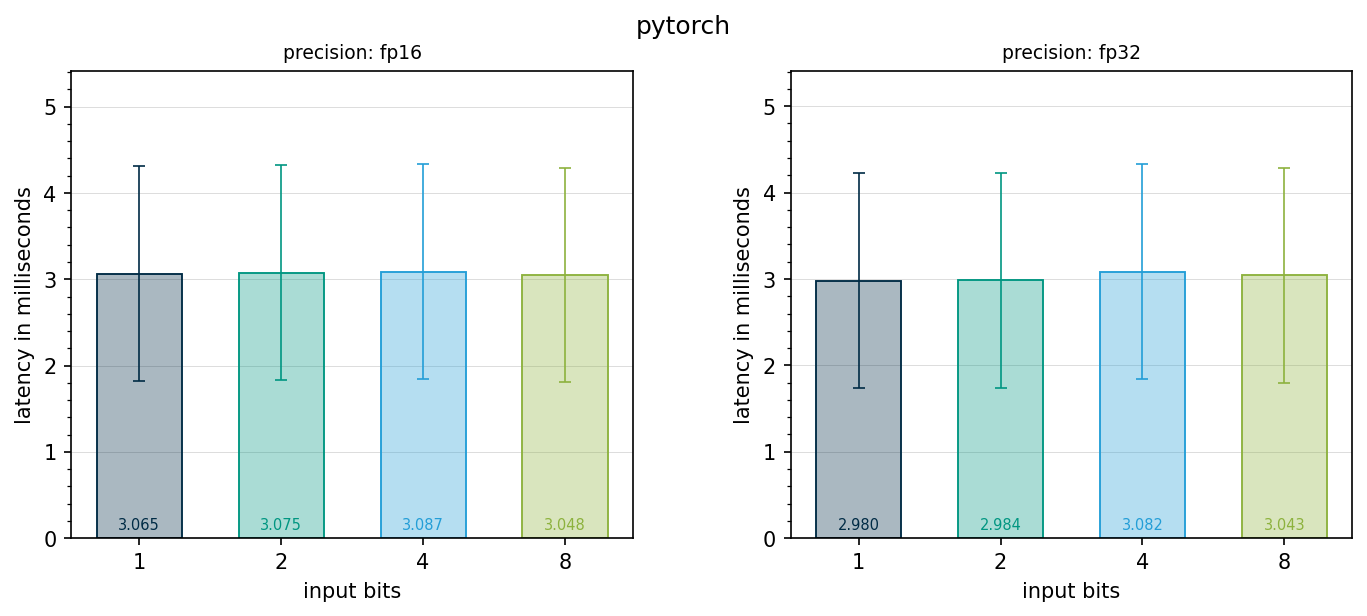

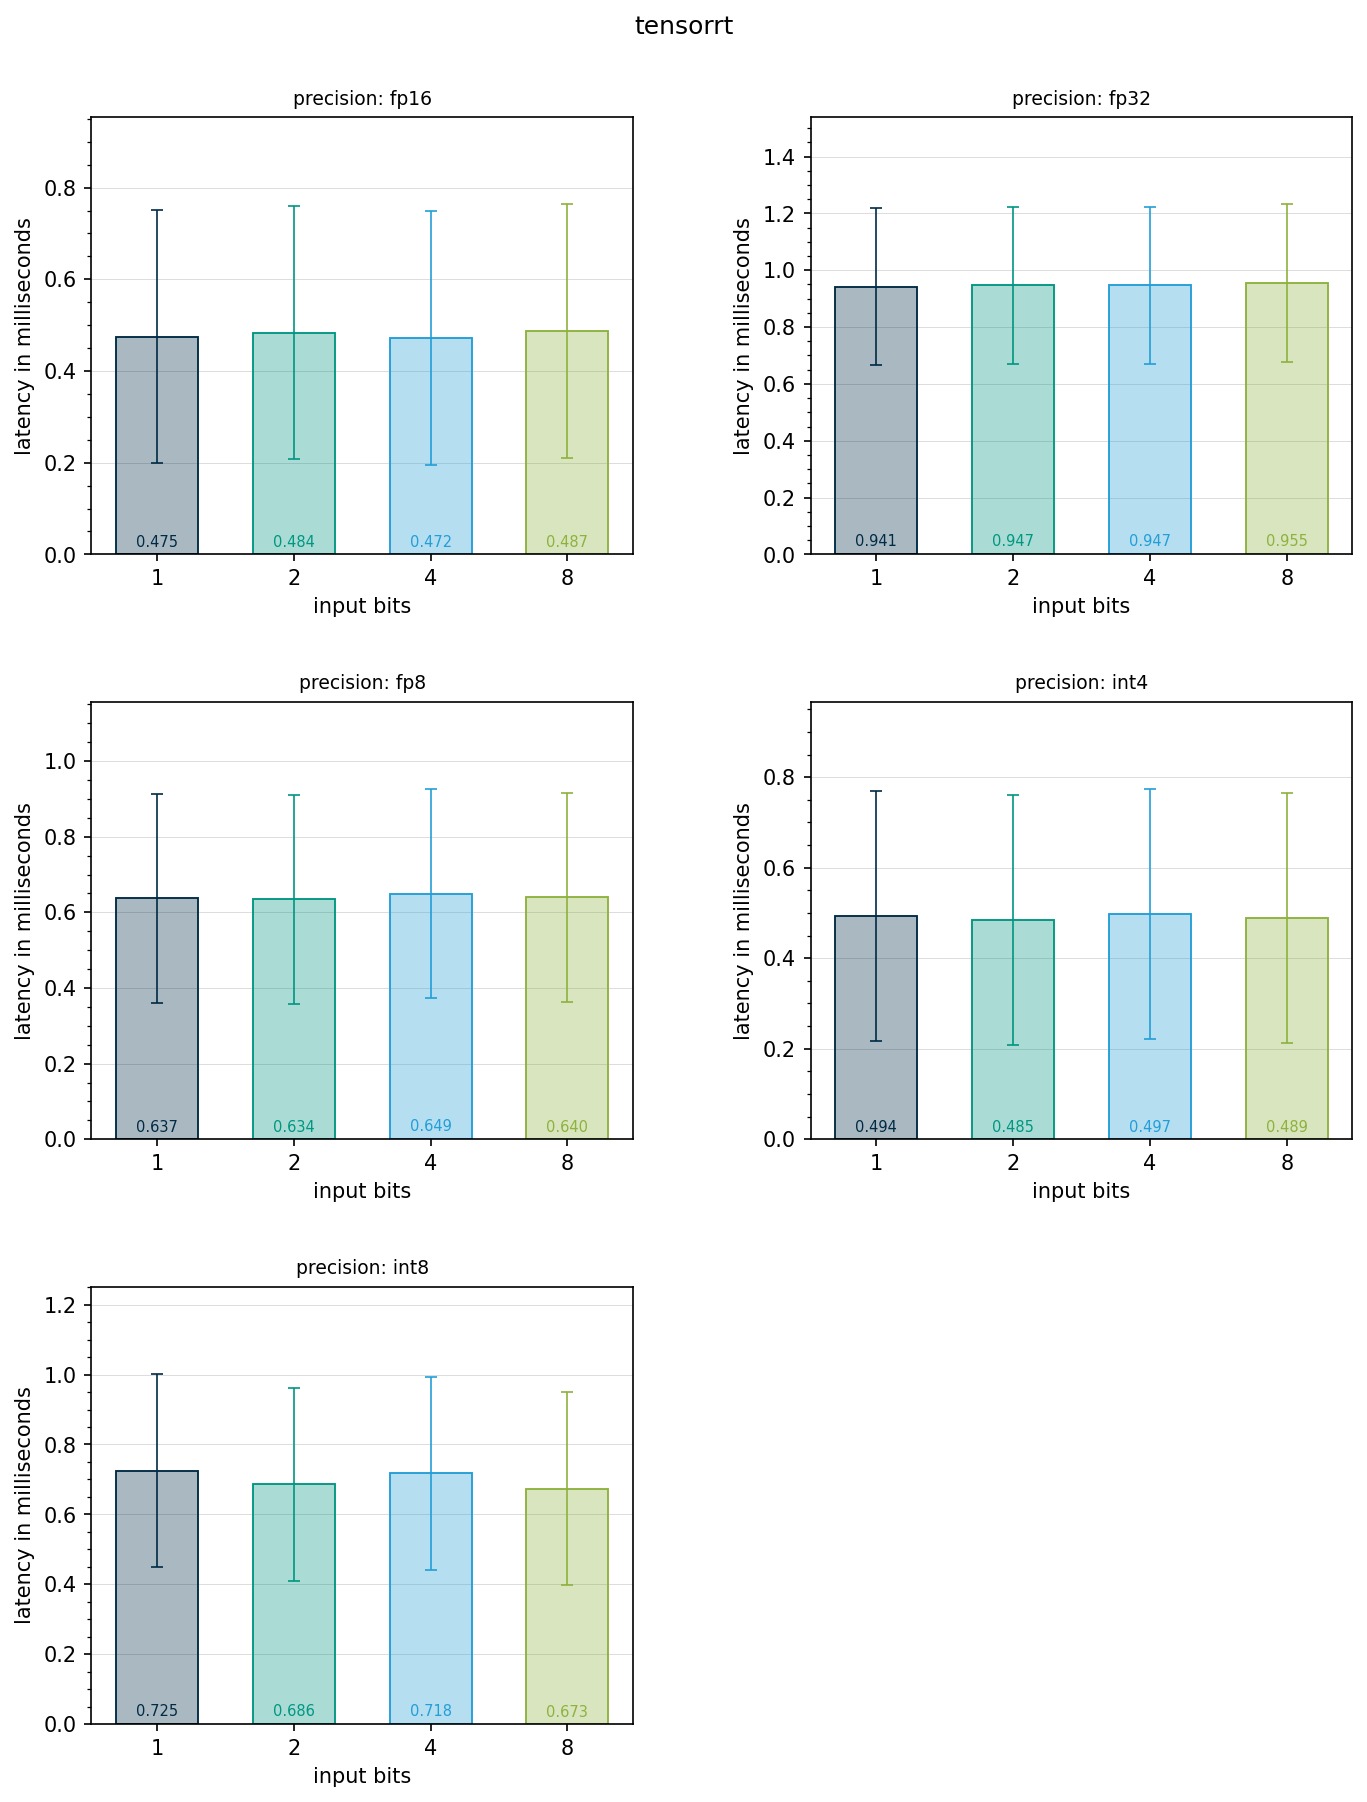

In [7]:
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = table_results[table_results["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
        )
        if grp.empty:
            continue

        grp = grp.copy()
        grp["input_bits"] = grp["input_bits"].astype(int)

        draw_bars(ax, grp, x_col="input_bits",
                  y_col="infer_ms_mean", yerr_col="infer_ms_std",
                  palette=BIT_PALETTE)
        ax.set_xlabel("input bits")
        ax.set_ylabel("latency in milliseconds")
        ax.set_title(f"precision: {prec}", fontsize=9)

    plt.show()

## Accuracy Bar Charts — top-1 & top-5 per backend/precision

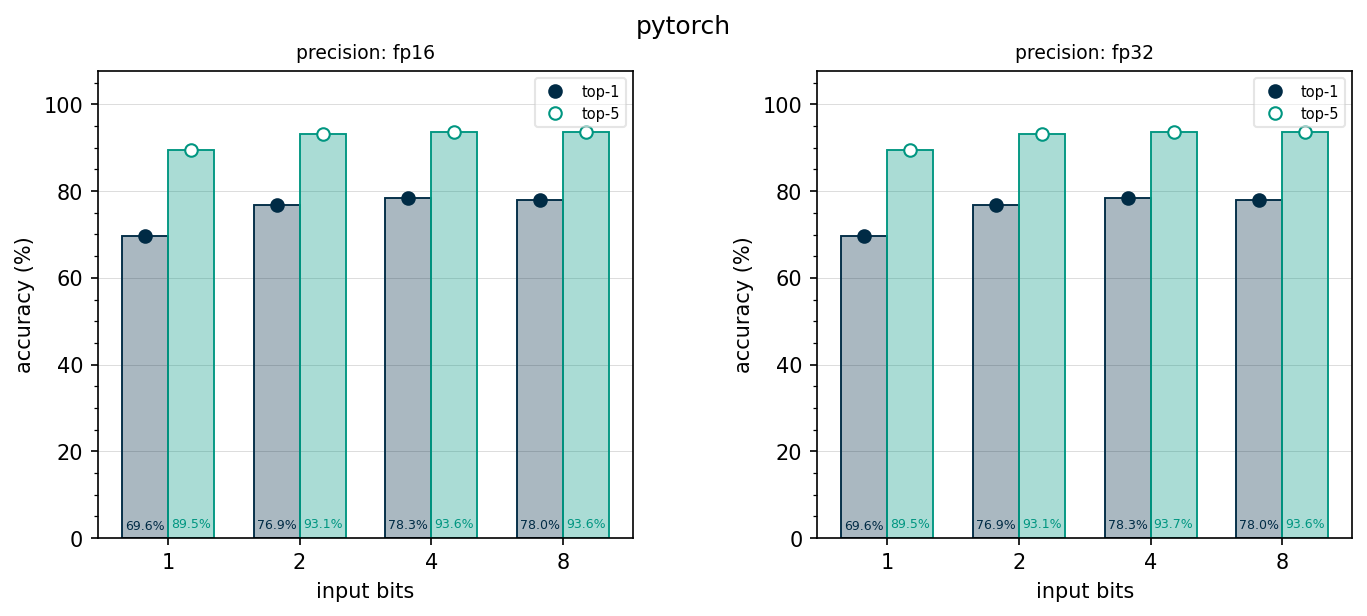

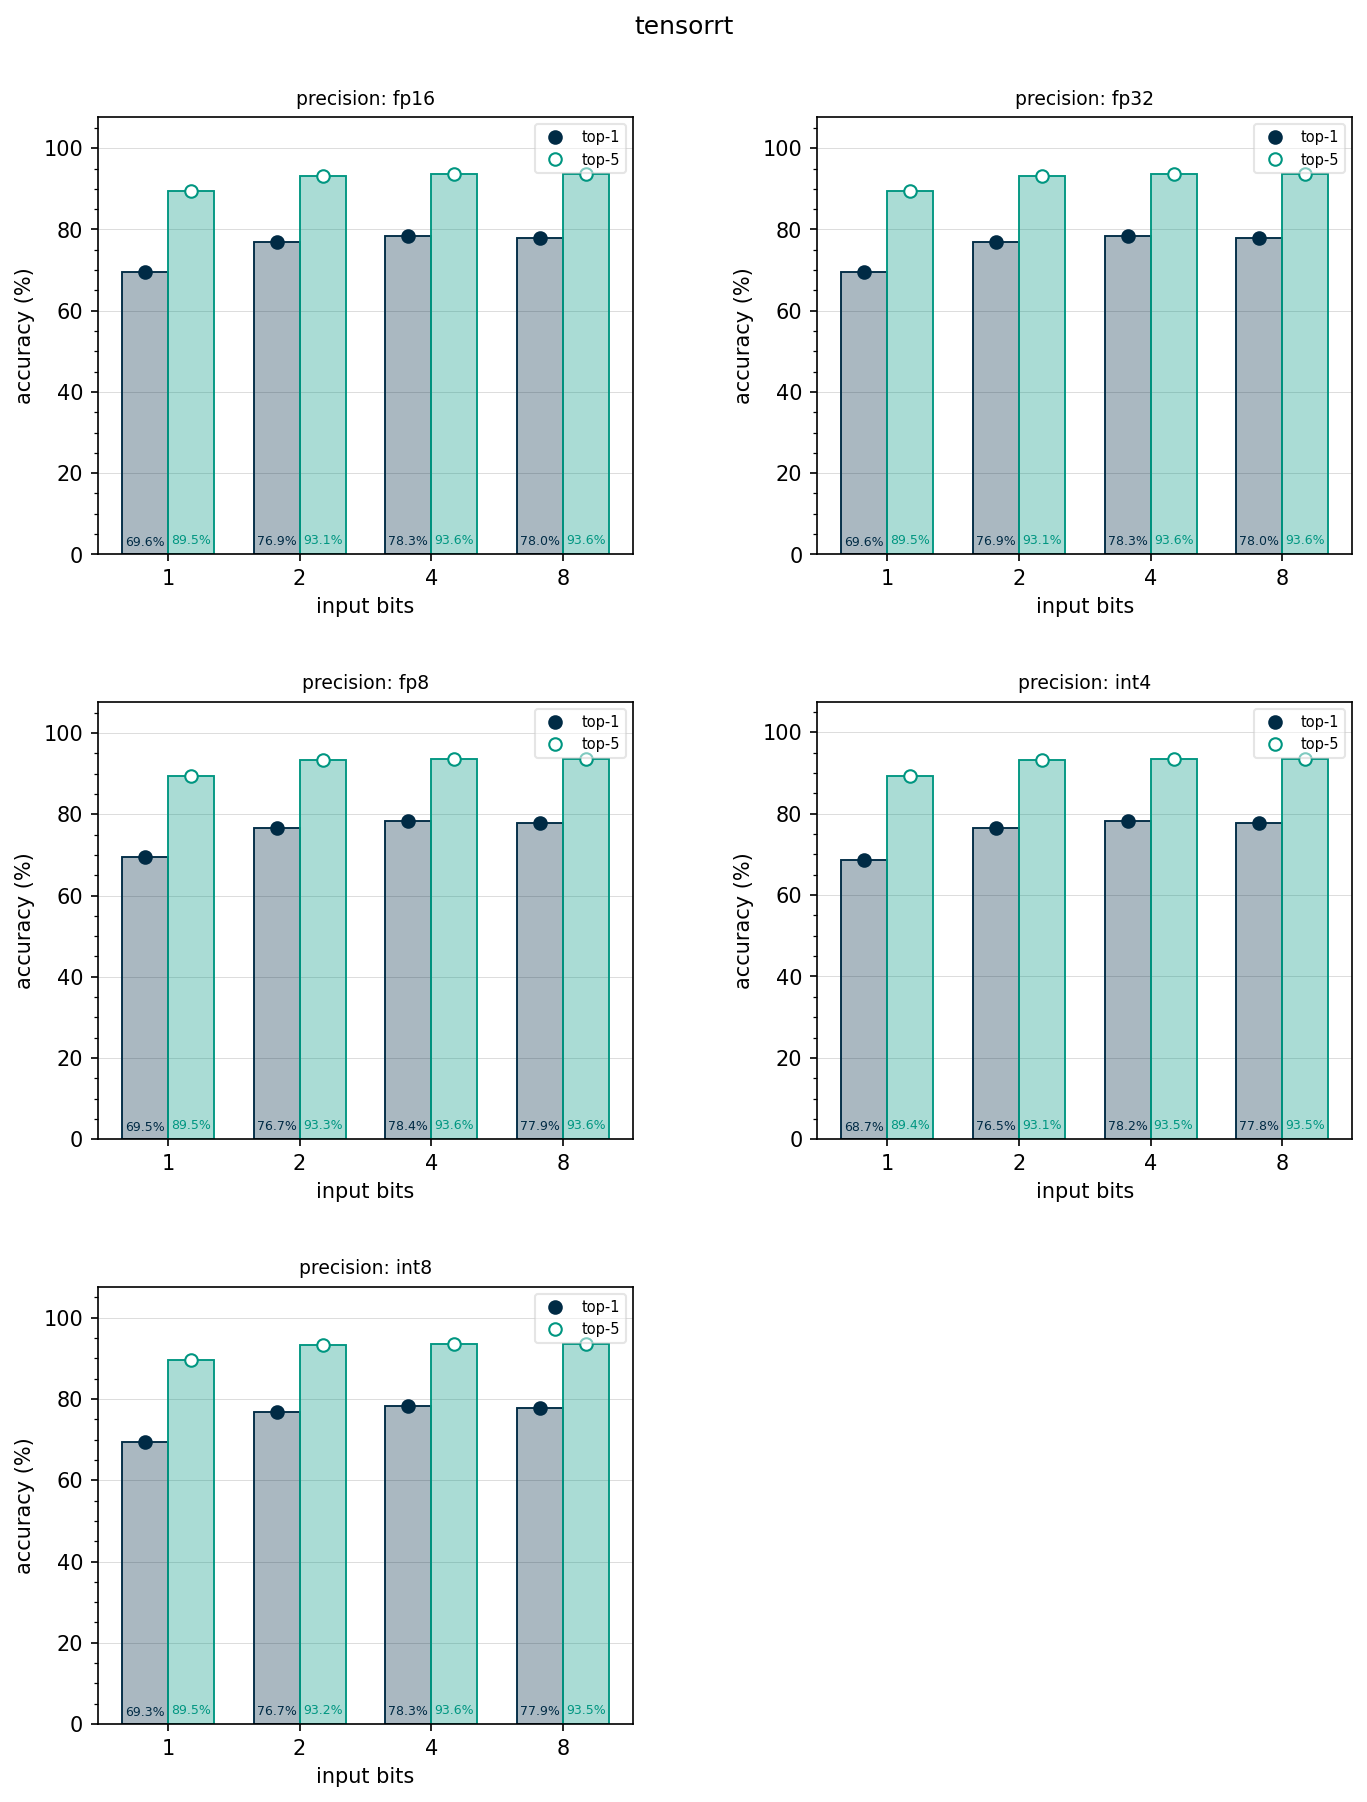

In [8]:
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = table_results[table_results["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        bits  = grp["input_bits"].astype(int).tolist()
        x_pos = np.arange(len(bits))
        width = 0.35

        ax.bar(x_pos - width/2, grp["top1_mean"], width=width,
               color="#002B4555", edgecolor="#002B45", linewidth=0.9, zorder=2)
        ax.bar(x_pos + width/2, grp["top5_mean"], width=width,
               color="#00968155", edgecolor="#009681", linewidth=0.9, zorder=2)

        ax.plot(x_pos - width/2, grp["top1_mean"], color="#002B45",
                marker="o", linestyle="none", markersize=6, label="top-1", zorder=3)
        ax.plot(x_pos + width/2, grp["top5_mean"], color="#009681",
                marker="o", linestyle="none", markersize=6,
                markerfacecolor="white", label="top-5", zorder=3)

        for xi, (_, row) in enumerate(grp.iterrows()):
            ax.text(xi - width/2, row["top1_mean"] * 0.02, f"{row['top1_mean']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#002B45", zorder=4)
            ax.text(xi + width/2, row["top5_mean"] * 0.02, f"{row['top5_mean']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#009681", zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(b) for b in bits])
        ax.set_xlabel("input bits")
        ax.set_ylabel("accuracy (%)")
        ax.set_title(f"precision: {prec}", fontsize=9)
        ax.set_ylim(0, grp[["top1_mean", "top5_mean"]].max().max() * 1.15)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
        ax.legend(fontsize=7, framealpha=0.5)

    plt.show()

## Accuracy vs Latency Scatter — all configs

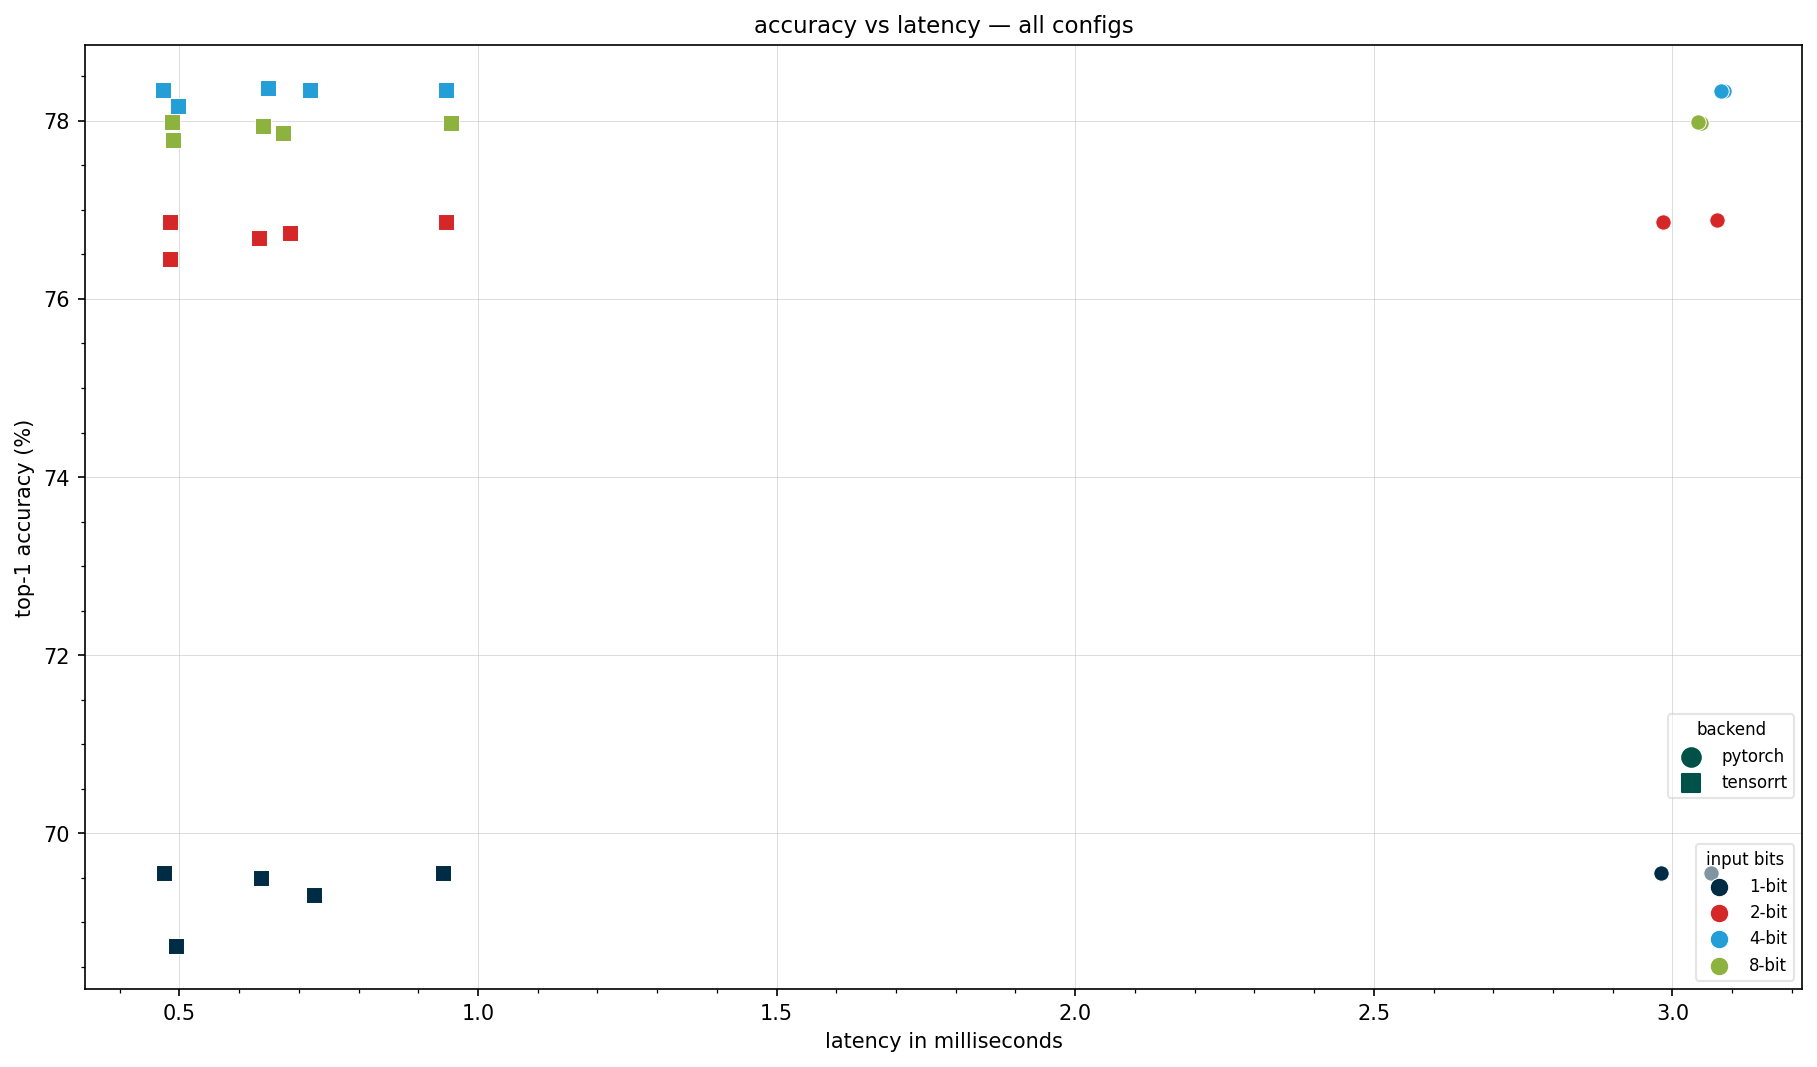

In [9]:
BACKEND_MARKERS = {"pytorch": "o", "tensorrt": "s"}
SCATTER_BIT_PALETTE = {1: "#002B45", 2: "#D62728", 4: "#239ED7", 8: "#8DB23E"}

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for backend, bgrp in table_results.groupby("backend"):
    marker = BACKEND_MARKERS.get(backend, "o")
    for _, row in bgrp.iterrows():
        bits  = int(row["input_bits"])
        color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
        ax.scatter(row["infer_ms_mean"], row["top1_mean"],
                   color=color, marker=marker, s=55, edgecolors="white",
                   linewidths=0.5, zorder=3)

ax.set_xlabel("latency in milliseconds")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — all configs", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in table_results["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    fontsize=8, title_fontsize=8, framealpha=0.5,
                    loc="lower right", markerscale=1.2)
ax.add_artist(legend1)

backend_handles = [
    plt.scatter([], [], color="#005148", marker=m, s=55, label=b)
    for b, m in BACKEND_MARKERS.items()
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(1, 0.3), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5, markerscale=1.2)

plt.show()

## Accuracy vs Latency — filtered (top1 > 74%, latency < 1.4 ms)

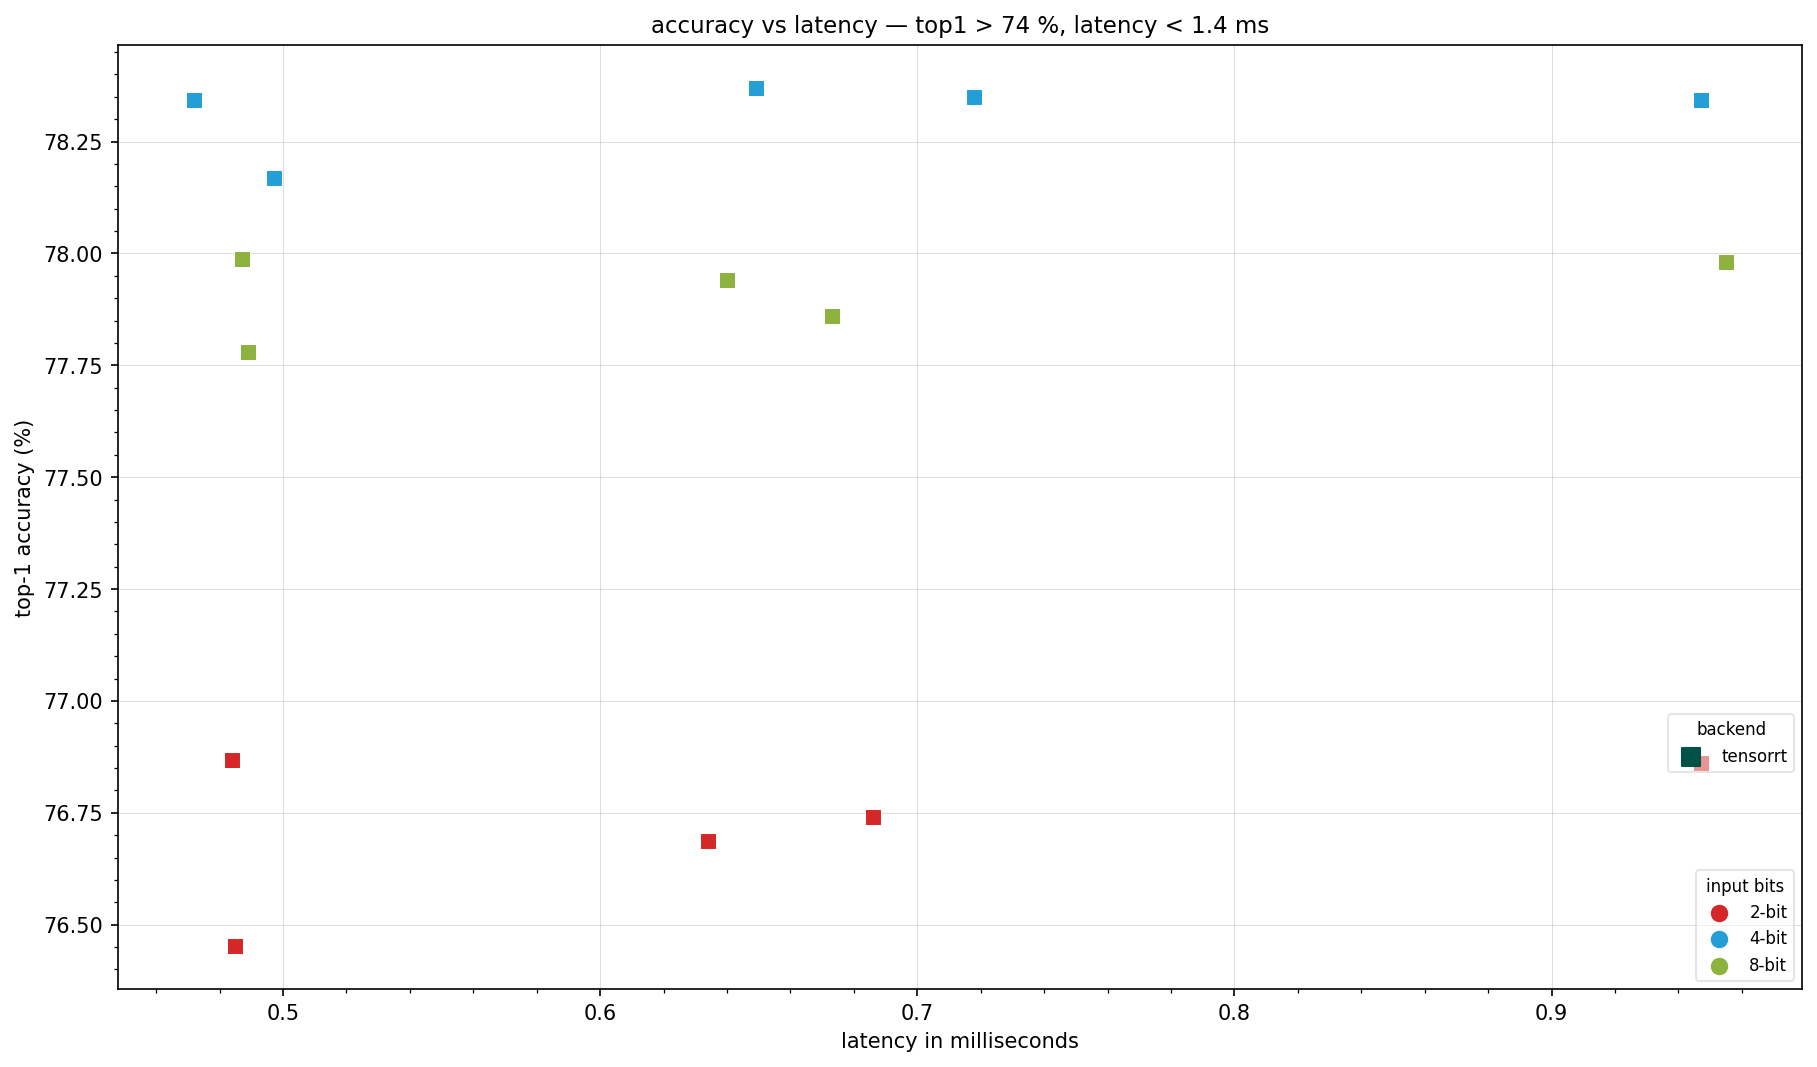

In [10]:
filtered = table_results[
    (table_results["top1_mean"] > 74) & (table_results["infer_ms_mean"] < 1.4)
]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for backend, bgrp in filtered.groupby("backend"):
    marker = BACKEND_MARKERS.get(backend, "o")
    for _, row in bgrp.iterrows():
        bits  = int(row["input_bits"])
        color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
        ax.scatter(row["infer_ms_mean"], row["top1_mean"],
                   color=color, marker=marker, s=55, edgecolors="white",
                   linewidths=0.5, zorder=3)

ax.set_xlabel("latency in milliseconds")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — top1 > 74 %, latency < 1.4 ms", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in filtered["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    fontsize=8, title_fontsize=8, framealpha=0.5,
                    loc="lower right", markerscale=1.2)
ax.add_artist(legend1)

backend_handles = [
    plt.scatter([], [], color="#005148", marker=m, s=55, label=b)
    for b, m in BACKEND_MARKERS.items()
    if b in filtered["backend"].values
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(1, 0.3), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5, markerscale=1.2)

plt.show()

## Ranked Latency — horizontal bars by input bits

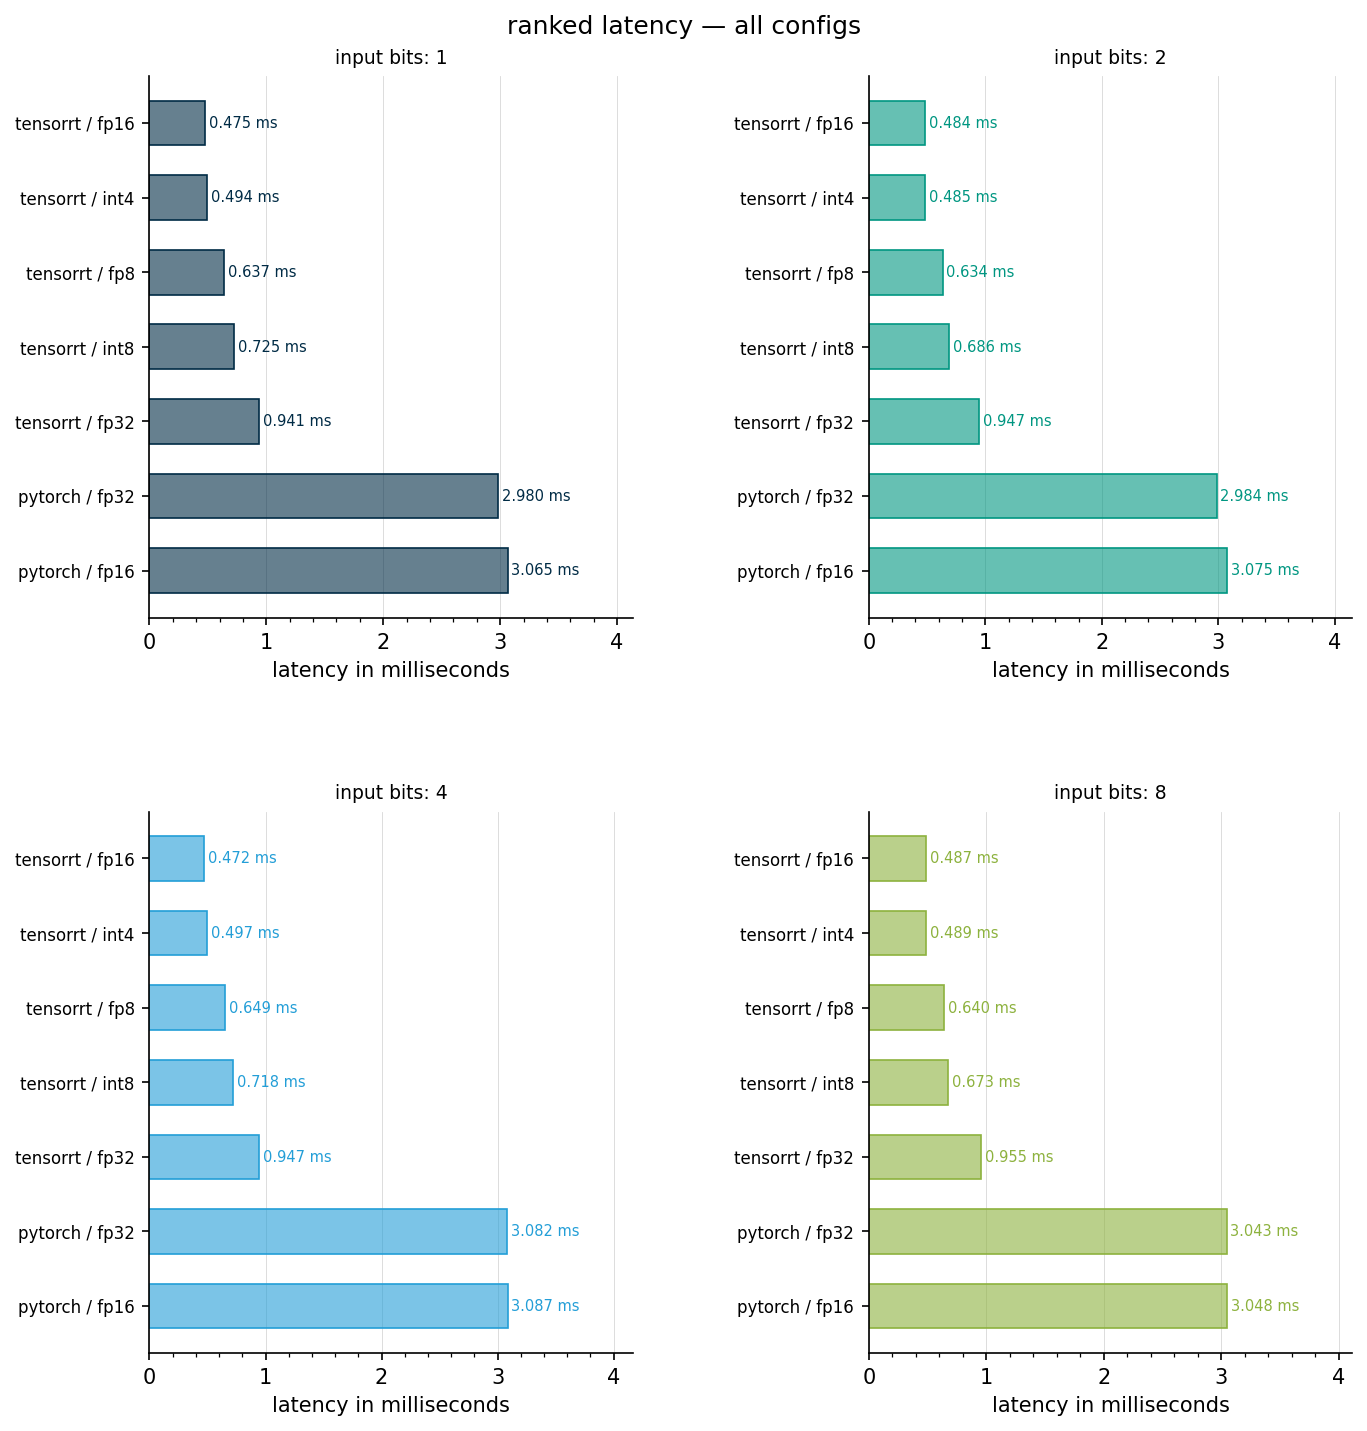

In [11]:
ranked = (
    table_results
    .sort_values("infer_ms_mean")
    .reset_index(drop=True)
)
ranked["label"] = ranked["backend"] + " / " + ranked["precision"]
ranked["input_bits"] = ranked["input_bits"].astype(int)

active_bits = sorted(ranked["input_bits"].unique())
n = len(active_bits)
nrows = math.ceil(n / COLS)

fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 0),
                         constrained_layout=True, squeeze=False)

max_bars = ranked.groupby("input_bits").size().max()
fig.set_size_inches(4.5 * COLS, max_bars * 0.55 * nrows + 1.5)
fig.suptitle("ranked latency — all configs", fontsize=12,
             x=0.5, ha="center", y=1.02)
fig.set_constrained_layout_pads(wspace=0.15, hspace=0.15)

ax_flat = axes.flatten()
for idx in range(n, len(ax_flat)):
    ax_flat[idx].set_visible(False)

for ax, bits in zip(ax_flat, active_bits):
    grp = ranked[ranked["input_bits"] == bits].sort_values("infer_ms_mean").reset_index(drop=True)
    if grp.empty:
        ax.set_visible(False)
        continue

    color = BIT_PALETTE.get(bits, "#7f7f7f")
    y_pos = np.arange(len(grp))

    ax.barh(y_pos, grp["infer_ms_mean"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.6, zorder=2)

    for yi, (_, row) in enumerate(grp.iterrows()):
        ax.text(row["infer_ms_mean"] + ax.get_xlim()[1] * 0.01, yi,
                f"{row['infer_ms_mean']:.3f} ms",
                ha="left", va="center", fontsize=7, color=color, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp["label"], fontsize=8)
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_xlabel("latency in milliseconds")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, grp["infer_ms_mean"].max() * 1.35)

plt.show()

## Ranked Accuracy — horizontal bars by input bits

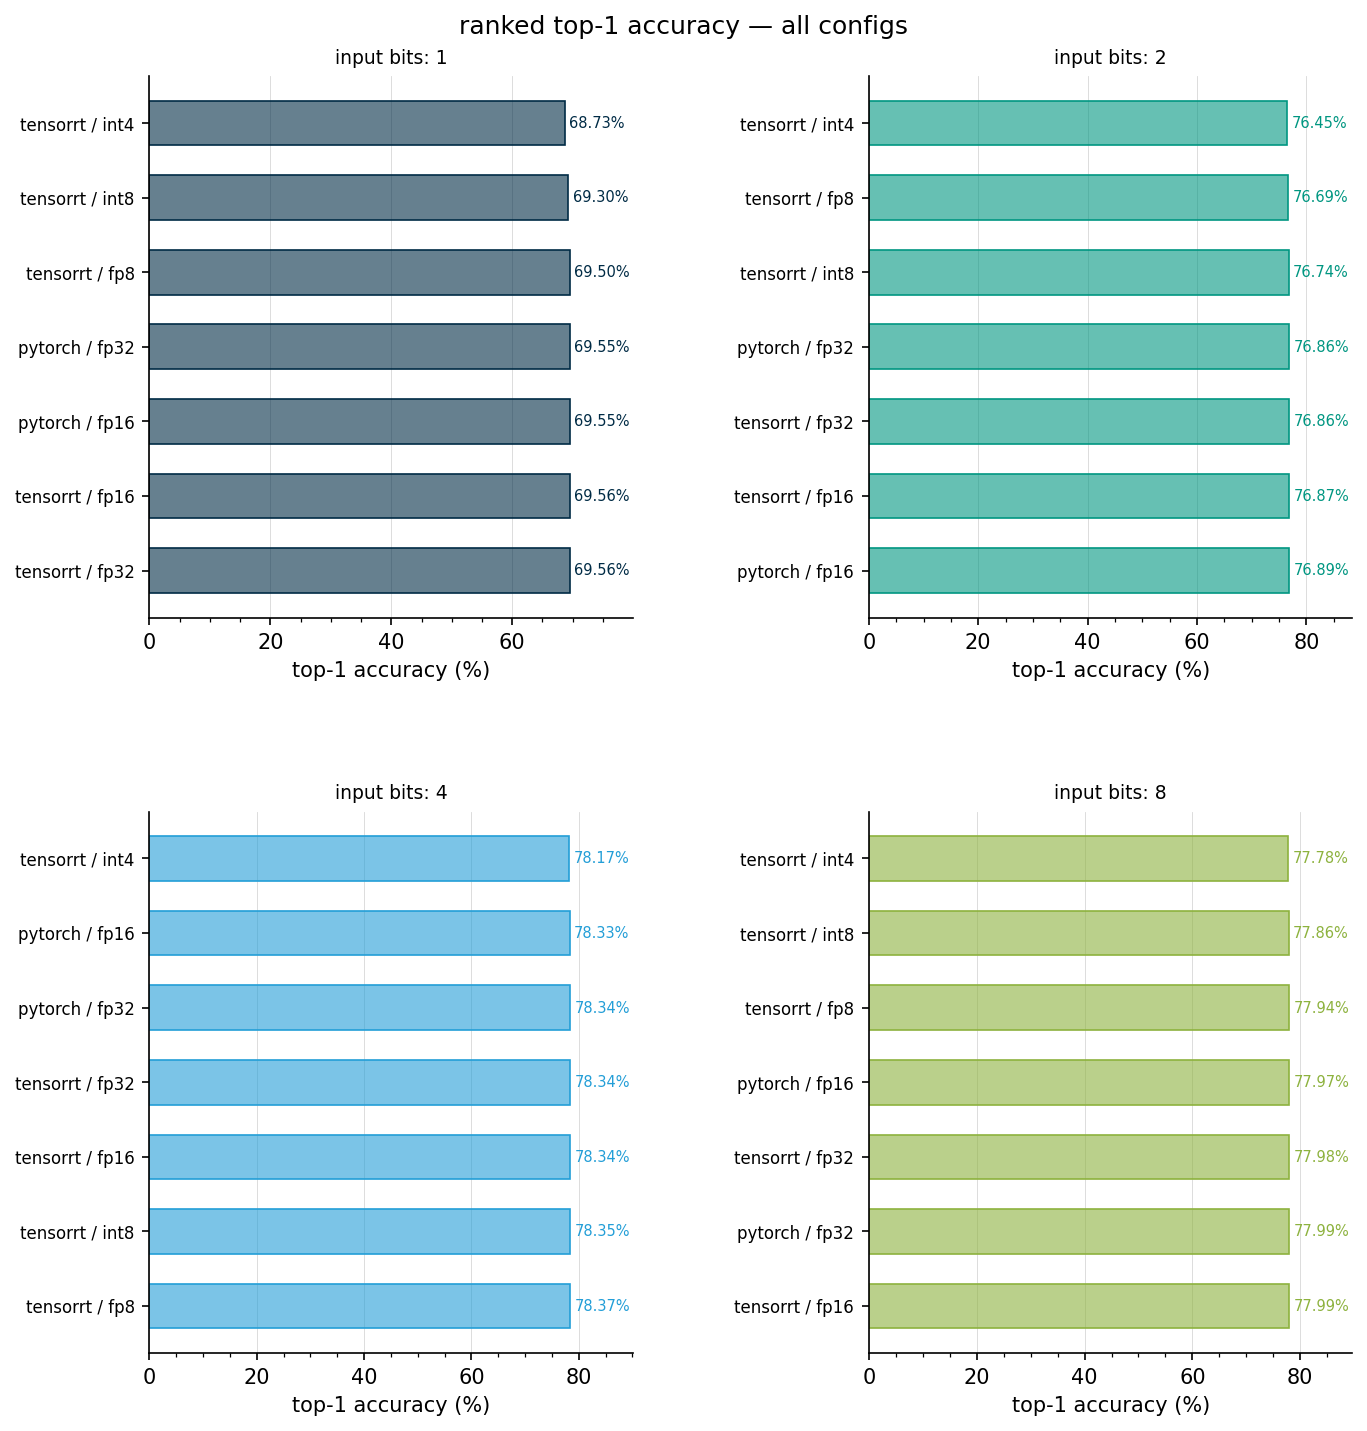

In [12]:
ranked_acc = (
    table_results
    .sort_values("top1_mean", ascending=False)
    .reset_index(drop=True)
)
ranked_acc["label"] = ranked_acc["backend"] + " / " + ranked_acc["precision"]
ranked_acc["input_bits"] = ranked_acc["input_bits"].astype(int)

active_bits = sorted(ranked_acc["input_bits"].unique())
n = len(active_bits)
nrows = math.ceil(n / COLS)

fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 0),
                         constrained_layout=True, squeeze=False)

max_bars = ranked_acc.groupby("input_bits").size().max()
fig.set_size_inches(4.5 * COLS, max_bars * 0.55 * nrows + 1.5)
fig.suptitle("ranked top-1 accuracy — all configs", fontsize=12,
             x=0.5, ha="center", y=1.02)
fig.set_constrained_layout_pads(wspace=0.15, hspace=0.15)

ax_flat = axes.flatten()
for idx in range(n, len(ax_flat)):
    ax_flat[idx].set_visible(False)

for ax, bits in zip(ax_flat, active_bits):
    grp = ranked_acc[ranked_acc["input_bits"] == bits].sort_values("top1_mean").reset_index(drop=True)
    if grp.empty:
        ax.set_visible(False)
        continue

    color = BIT_PALETTE.get(bits, "#7f7f7f")
    y_pos = np.arange(len(grp))

    ax.barh(y_pos, grp["top1_mean"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.6, zorder=2)

    for yi, (_, row) in enumerate(grp.iterrows()):
        ax.text(row["top1_mean"] + ax.get_xlim()[1] * 0.01, yi,
                f"{row['top1_mean']:.2f}%",
                ha="left", va="center", fontsize=7, color=color, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp["label"], fontsize=8)
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_xlabel("top-1 accuracy (%)")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, grp["top1_mean"].max() * 1.15)

plt.show()

## Speedup vs Baseline (pytorch/fp32/8-bit) — all configs

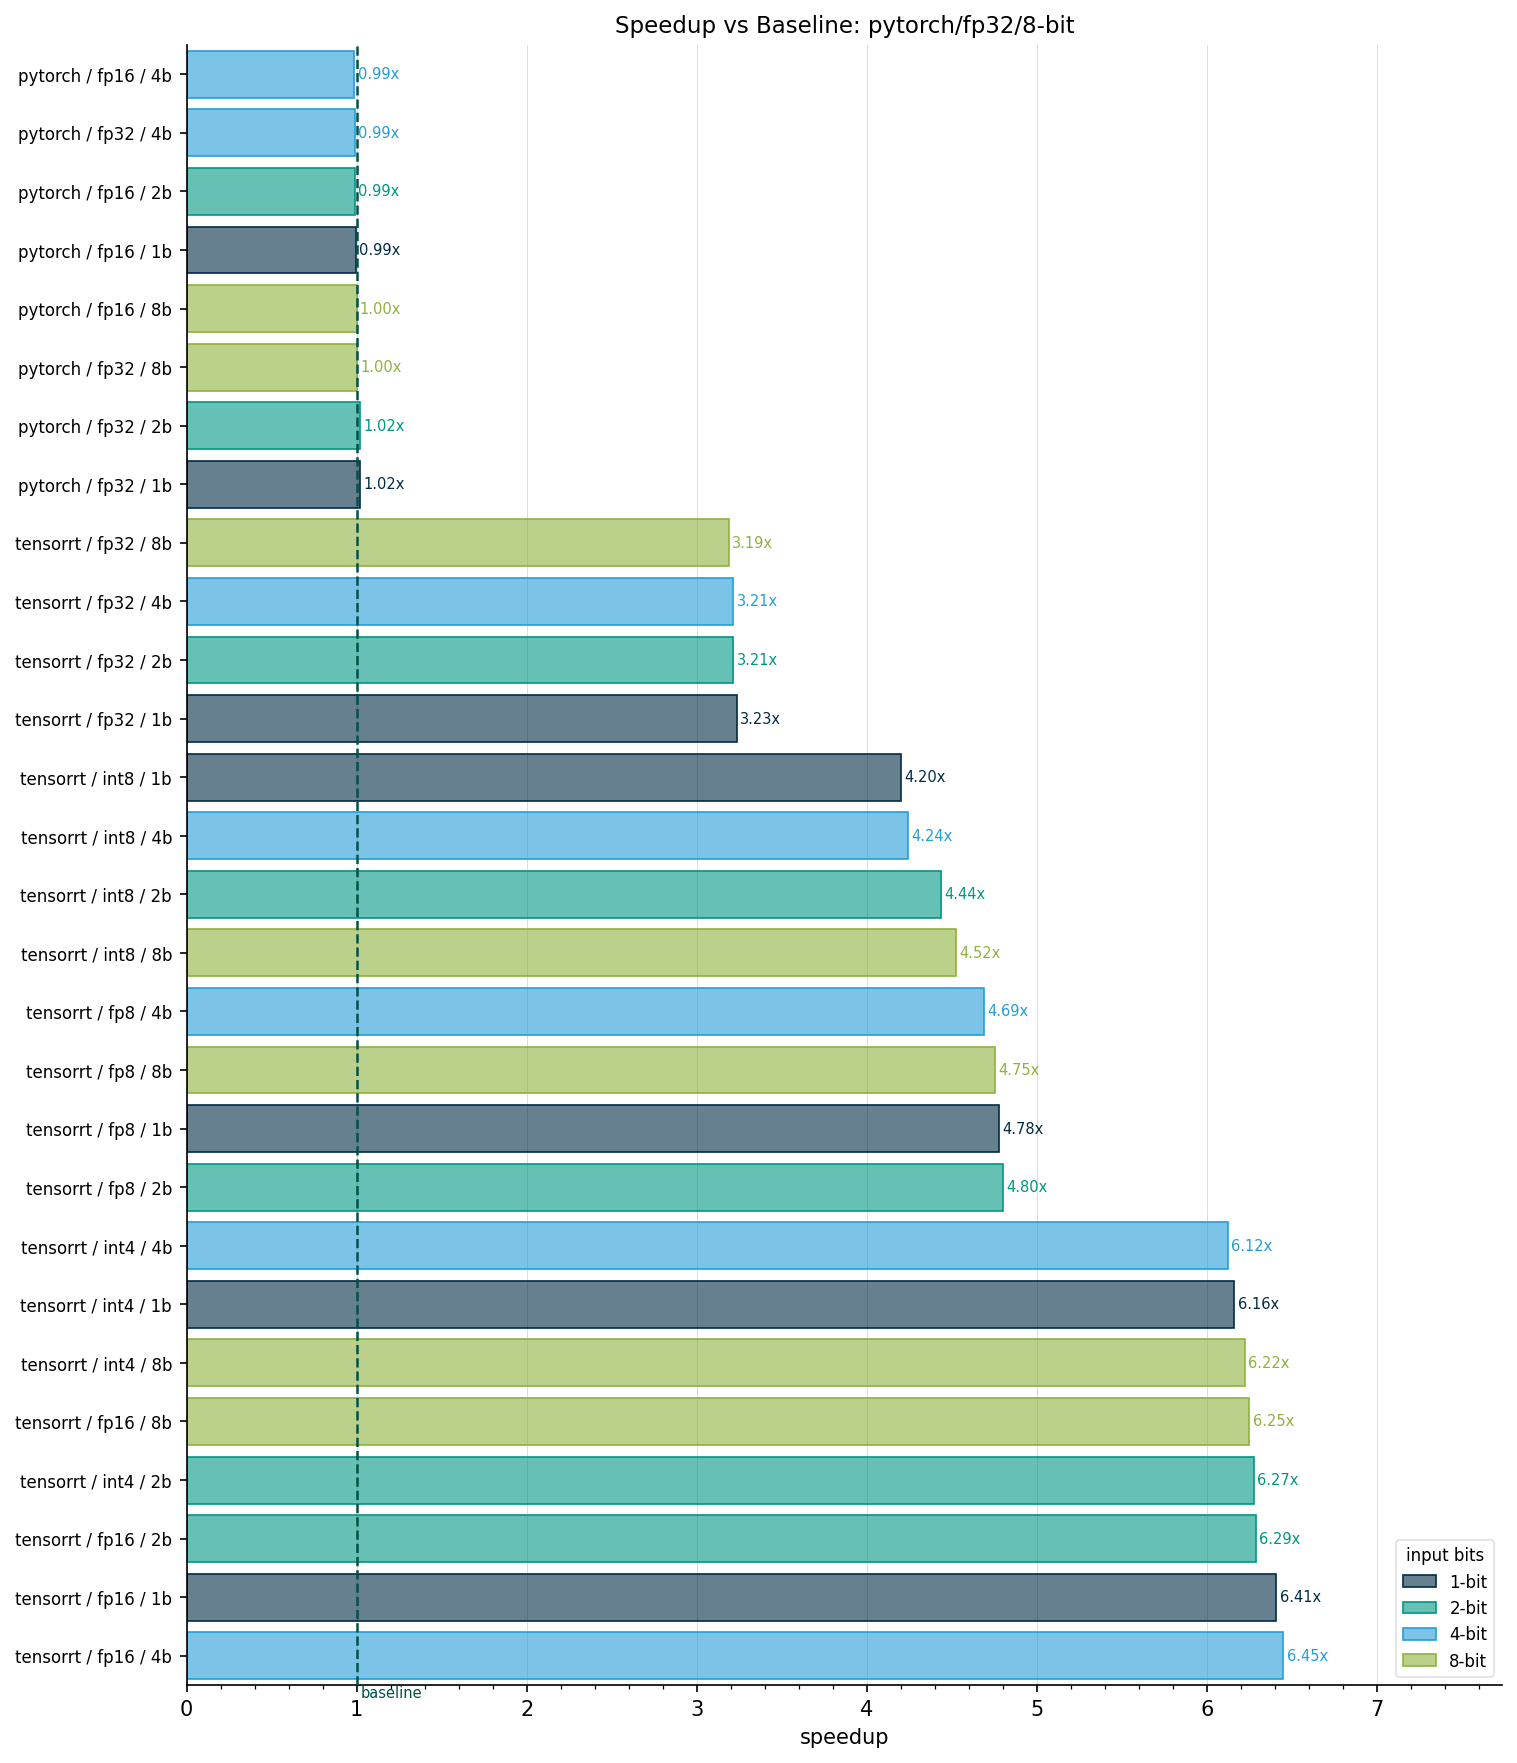

In [13]:
baseline = table_results[
    (table_results["backend"] == "pytorch") &
    (table_results["precision"] == "fp32") &
    (table_results["input_bits"] == 8)
]["infer_ms_mean"].values[0]

speedup = table_results.copy()
speedup["speedup"]    = baseline / speedup["infer_ms_mean"]
speedup["label"]      = (speedup["backend"] + " / " +
                         speedup["precision"] + " / " +
                         speedup["input_bits"].astype(int).astype(str) + "b")
speedup["input_bits"] = speedup["input_bits"].astype(int)

speedup = speedup.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup.iterrows()):
    bits  = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3, label="baseline")
ax.text(1.02, len(speedup) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup)))
ax.set_yticklabels(speedup["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.set_xlim(0, speedup["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in speedup["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

## Speedup vs Baseline — 8-bit input only

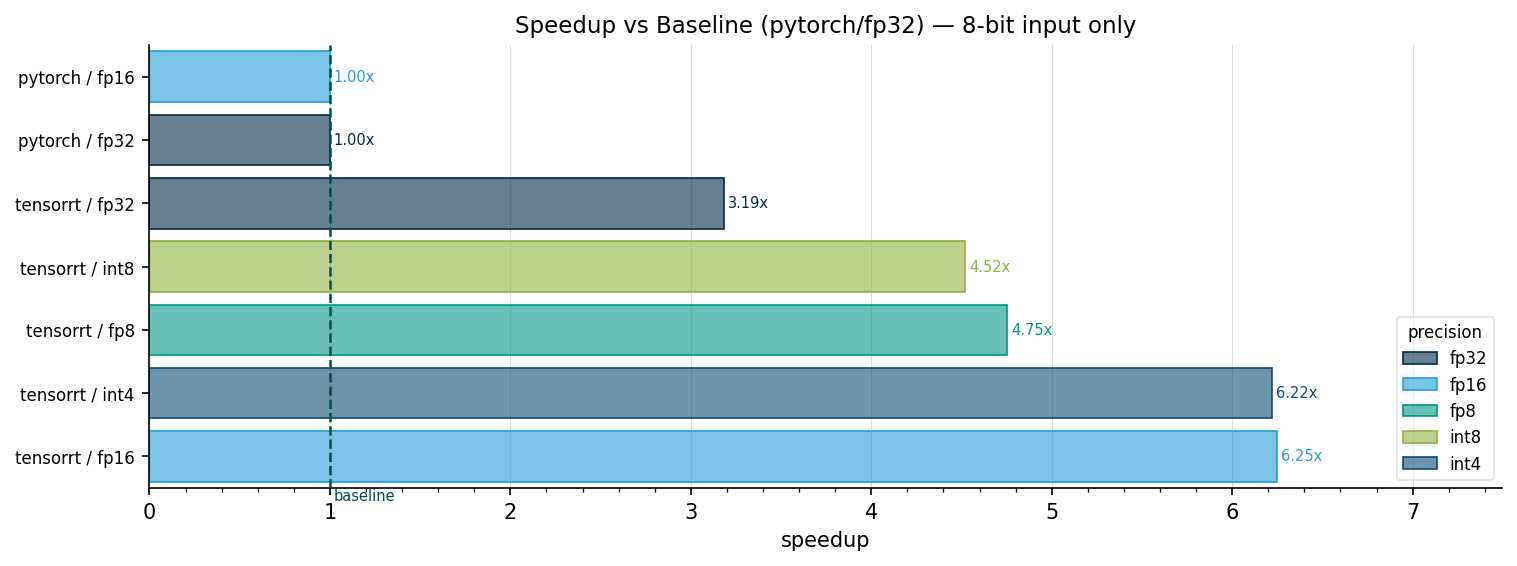

In [14]:
speedup_8 = table_results[table_results["input_bits"] == 8].copy()
speedup_8["speedup"] = baseline / speedup_8["infer_ms_mean"]
speedup_8["label"]   = speedup_8["backend"] + " / " + speedup_8["precision"]

speedup_8 = speedup_8.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup_8) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup_8.iterrows()):
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(1.02, len(speedup_8) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup_8)))
ax.set_yticklabels(speedup_8["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline (pytorch/fp32) — 8-bit input only", fontsize=11)
ax.set_xlim(0, speedup_8["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup_8) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_precs = [p for p in PREC_PALETTE if p in speedup_8["precision"].values]
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=PREC_PALETTE[p] + "99",
                  edgecolor=PREC_PALETTE[p], linewidth=0.8,
                  label=p)
    for p in present_precs
]
ax.legend(handles=handles, title="precision", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

## Accuracy Drop vs Baseline (pytorch/fp32/8-bit)

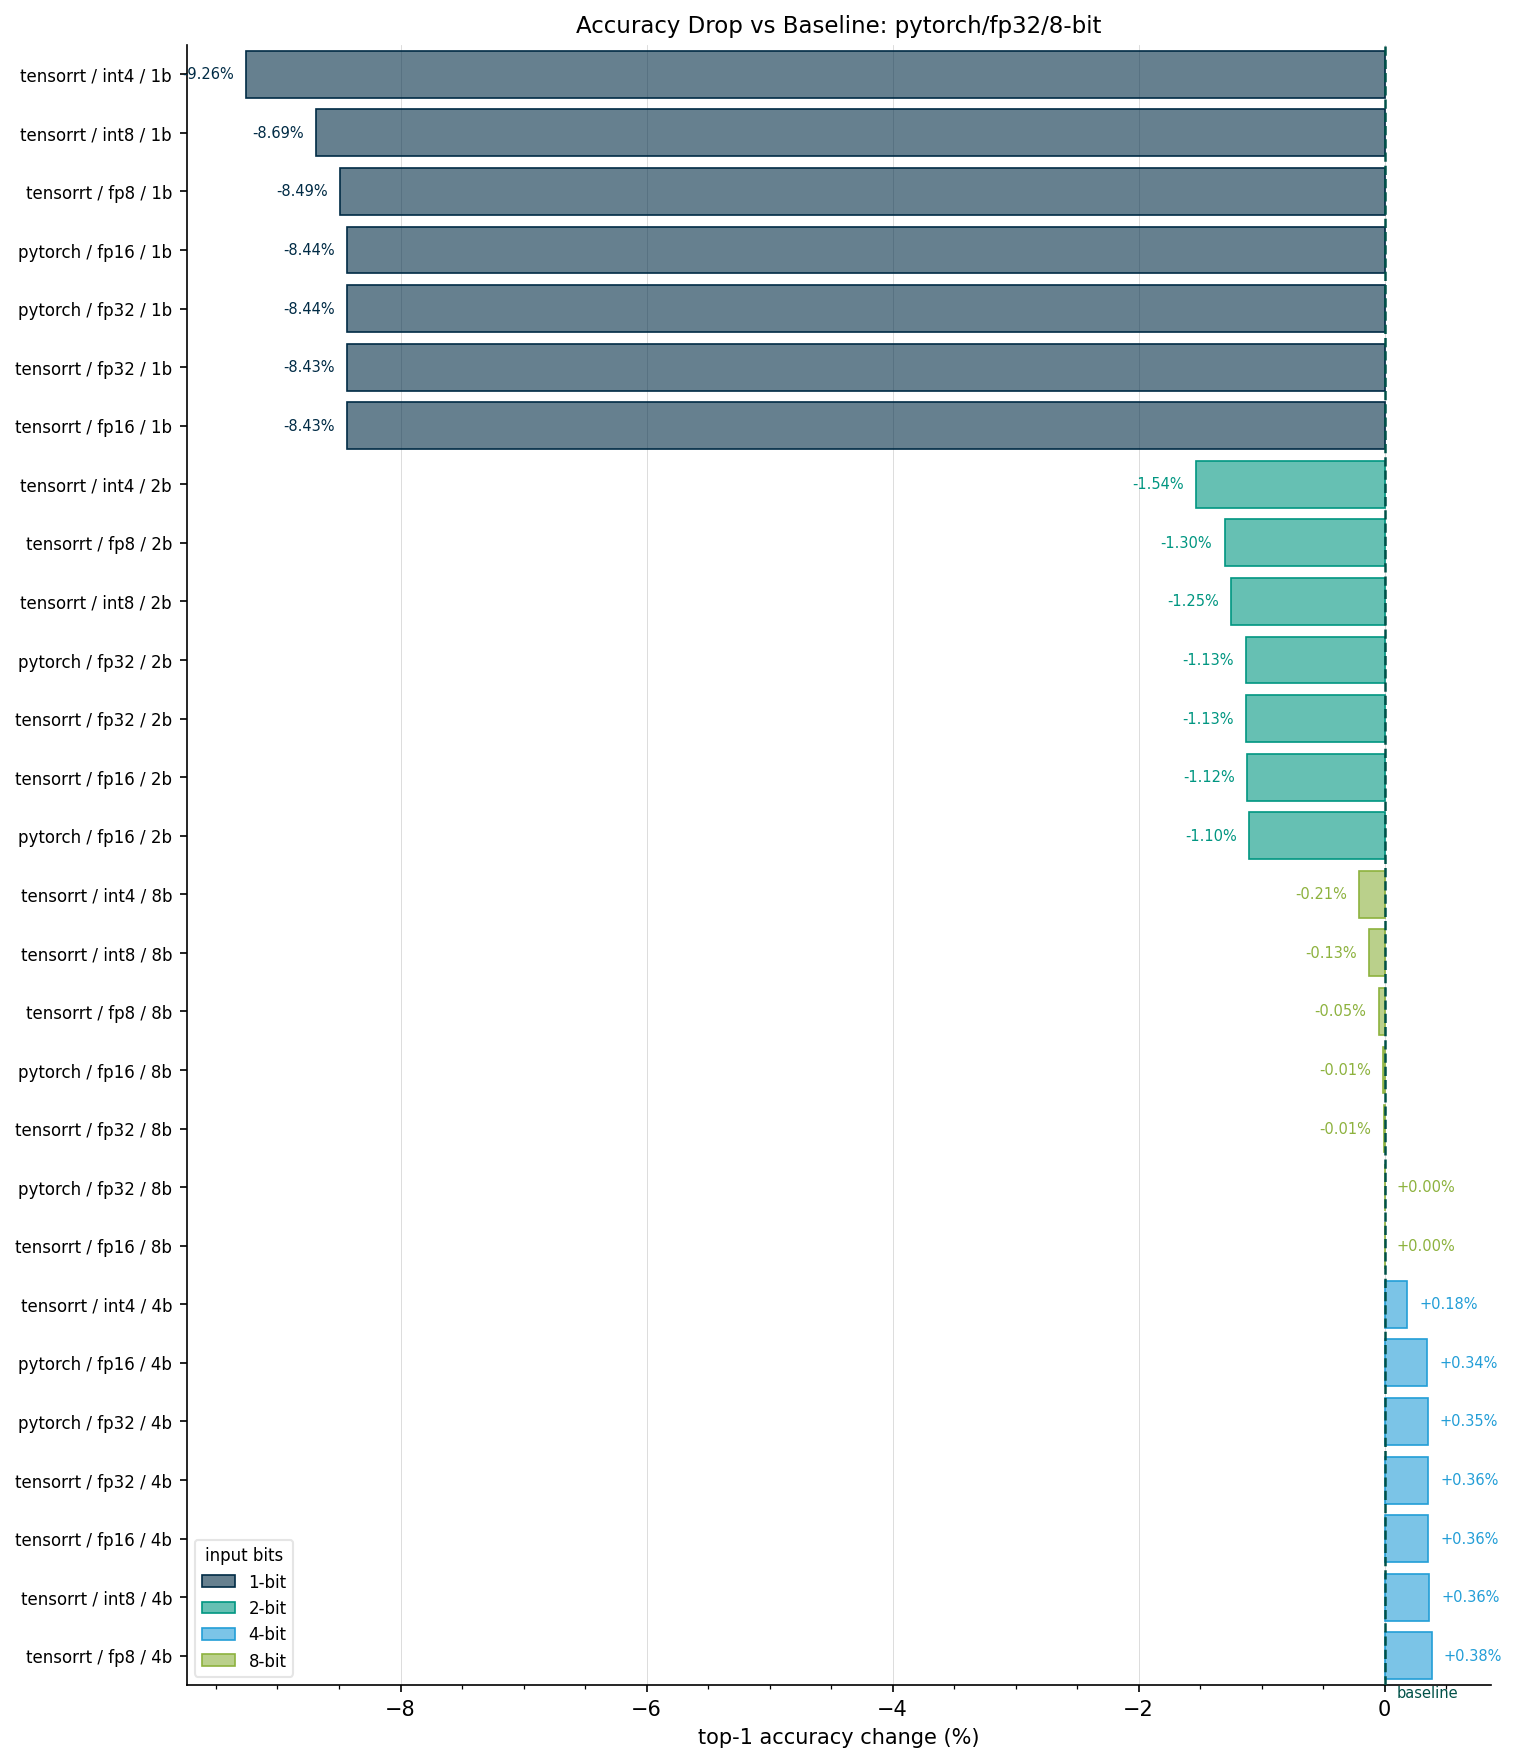

In [15]:
baseline_top1 = table_results[
    (table_results["backend"] == "pytorch") &
    (table_results["precision"] == "fp32") &
    (table_results["input_bits"] == 8)
]["top1_mean"].values[0]

acc = table_results.copy()
acc["acc_drop"]    = acc["top1_mean"] - baseline_top1
acc["label"]       = (acc["backend"] + " / " +
                      acc["precision"] + " / " +
                      acc["input_bits"].astype(int).astype(str) + "b")
acc["input_bits"]  = acc["input_bits"].astype(int)

acc = acc.sort_values("acc_drop", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(acc) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(acc.iterrows()):
    bits  = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["acc_drop"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    sign = "+" if row["acc_drop"] >= 0 else ""
    offset = 0.1 if row["acc_drop"] >= 0 else -0.1
    ax.text(row["acc_drop"] + offset, yi,
            f"{sign}{row['acc_drop']:.2f}%",
            ha="left" if row["acc_drop"] >= 0 else "right",
            va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=0.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(0.1, len(acc) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(acc)))
ax.set_yticklabels(acc["label"], fontsize=8)
ax.set_xlabel("top-1 accuracy change (%)")
ax.set_title("Accuracy Drop vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(acc) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in acc["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower left")

plt.show()

## PTQ INT8 vs QAT INT8 — TensorRT Accuracy

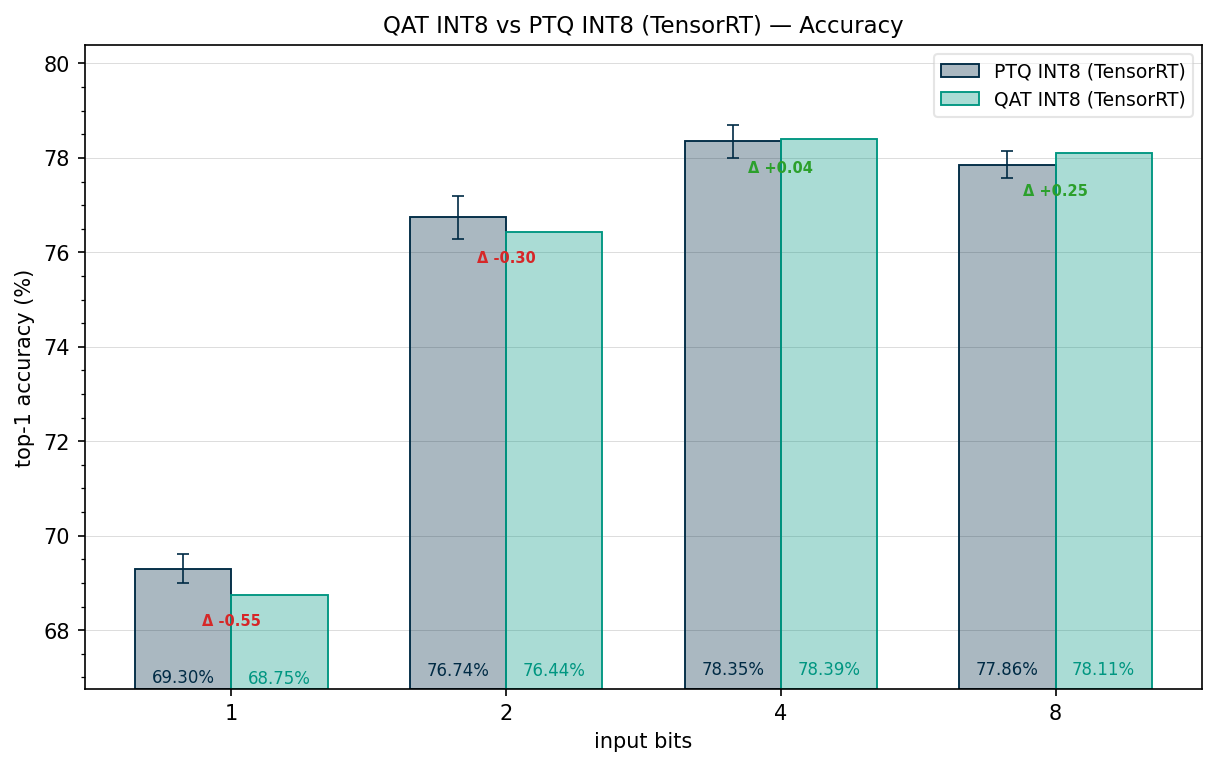

In [16]:
ptq_int8 = combined[
    (combined["backend"] == "tensorrt") & (combined["precision"] == "int8")
].sort_values("input_bits").reset_index(drop=True)

qat_int8 = combined[
    (combined["backend"] == "tensorrt") & (combined["precision"] == "qat_int8")
].sort_values("input_bits").reset_index(drop=True)

bits = ptq_int8["input_bits"].astype(int).tolist()
x_pos = np.arange(len(bits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ptq_color = "#002B45"
qat_color = "#009681"

y_min = min(ptq_int8["top1_mean"].min(), qat_int8["top1_mean"].min()) - 2
y_max = max(ptq_int8["top1_mean"].max(), qat_int8["top1_mean"].max()) + 2
ax.set_ylim(y_min, y_max)

ax.bar(x_pos - width / 2, ptq_int8["top1_mean"] - y_min, width=width,
       bottom=y_min,
       color=ptq_color + "55", edgecolor=ptq_color, linewidth=0.9, zorder=2,
       label="PTQ INT8 (TensorRT)")
ax.errorbar(x_pos - width / 2, ptq_int8["top1_mean"], yerr=ptq_int8["top1_std"],
            fmt="none", ecolor=ptq_color, **eb_kw)

ax.bar(x_pos + width / 2, qat_int8["top1_mean"] - y_min, width=width,
       bottom=y_min,
       color=qat_color + "55", edgecolor=qat_color, linewidth=0.9, zorder=2,
       label="QAT INT8 (TensorRT)")

for xi in range(len(bits)):
    ptq_val = ptq_int8.iloc[xi]["top1_mean"]
    qat_val = qat_int8.iloc[xi]["top1_mean"]
    delta = qat_val - ptq_val

    ax.text(xi - width / 2, y_min + (ptq_val - y_min) * 0.02,
            f"{ptq_val:.2f}%",
            ha="center", va="bottom", fontsize=8, color=ptq_color, zorder=4)
    ax.text(xi + width / 2, y_min + (qat_val - y_min) * 0.02,
            f"{qat_val:.2f}%",
            ha="center", va="bottom", fontsize=8, color=qat_color, zorder=4)

    sign = "+" if delta >= 0 else ""
    delta_color = "#D62728" if delta < 0 else "#2ca02c"
    ax.text(xi, min(ptq_val, qat_val) - 0.4,
            f"Δ {sign}{delta:.2f}",
            ha="center", va="top", fontsize=7, fontweight="bold",
            color=delta_color, zorder=4)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits])
ax.set_xlabel("input bits")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("QAT INT8 vs PTQ INT8 (TensorRT) — Accuracy", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
ax.legend(fontsize=9, framealpha=0.5)

plt.show()

## QAT INT4 vs QAT INT8 vs FP32 (PyTorch) — Accuracy

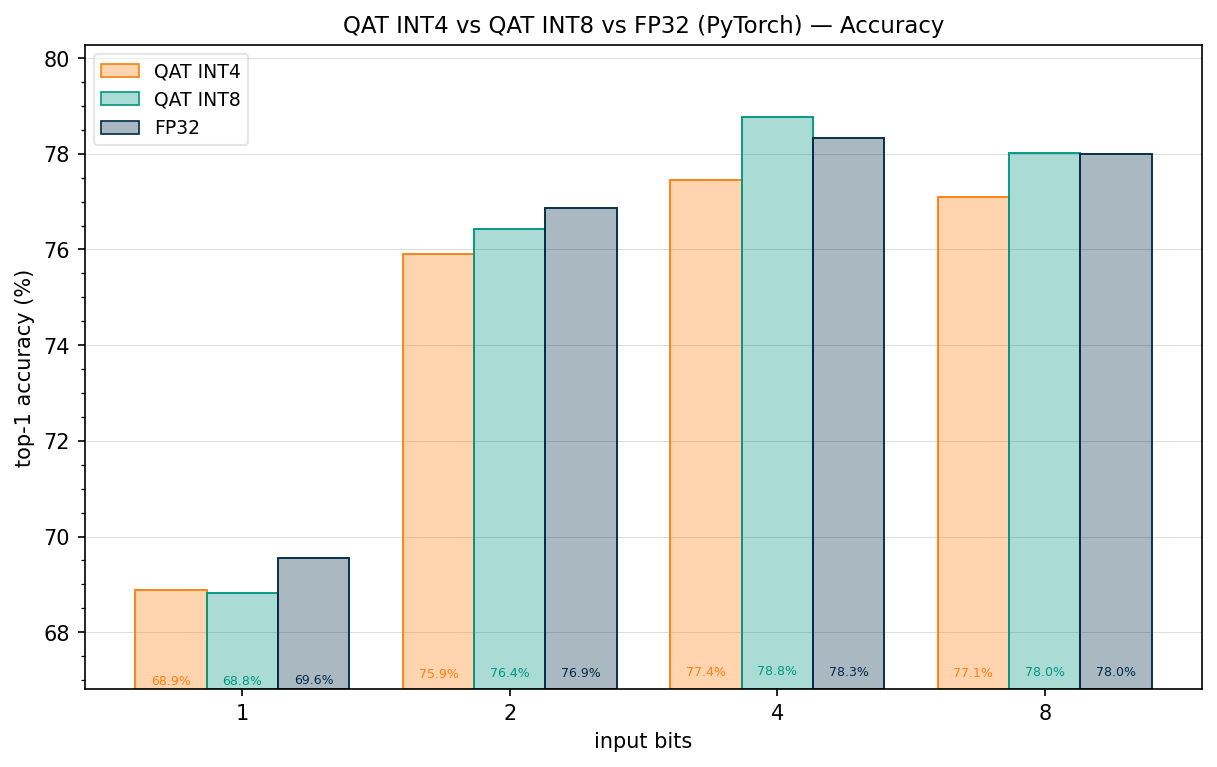

In [17]:
qat_i4 = table_qat[table_qat["precision"] == "qat_int4"].sort_values("input_bits").reset_index(drop=True)
qat_i8 = table_qat[table_qat["precision"] == "qat_int8"].sort_values("input_bits").reset_index(drop=True)
pt_fp32 = table_results[
    (table_results["backend"] == "pytorch") & (table_results["precision"] == "fp32")
].sort_values("input_bits").reset_index(drop=True)

groups = [
    ("QAT INT4", qat_i4, QAT_PALETTE["qat_int4"]),
    ("QAT INT8", qat_i8, QAT_PALETTE["qat_int8"]),
    ("FP32",     pt_fp32, PREC_PALETTE["fp32"]),
]

bits_list = sorted(pt_fp32["input_bits"].astype(int).unique())
x_pos = np.arange(len(bits_list))
n_grp = len(groups)
width = 0.8 / n_grp

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

all_vals = pd.concat([g[1]["top1_mean"] for g in groups])
y_bottom = all_vals.min() - 2
y_top = all_vals.max() + 1.5
ax.set_ylim(y_bottom, y_top)

for gi, (label, grp, color) in enumerate(groups):
    offset = (gi - (n_grp - 1) / 2) * width
    for i, (_, row) in enumerate(grp.iterrows()):
        ax.bar(x_pos[i] + offset, row["top1_mean"] - y_bottom, width,
               bottom=y_bottom,
               color=color + "55", edgecolor=color, linewidth=0.9, zorder=2)
        ax.text(x_pos[i] + offset, y_bottom + (row["top1_mean"] - y_bottom) * 0.02,
                f"{row['top1_mean']:.1f}%", ha="center", va="bottom",
                fontsize=6, color=color, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits_list])
ax.set_xlabel("input bits")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("QAT INT4 vs QAT INT8 vs FP32 (PyTorch) — Accuracy", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c,
                  linewidth=0.8, label=lbl)
    for lbl, _, c in groups
]
ax.legend(handles=handles, fontsize=9, framealpha=0.5, loc="upper left")

plt.show()

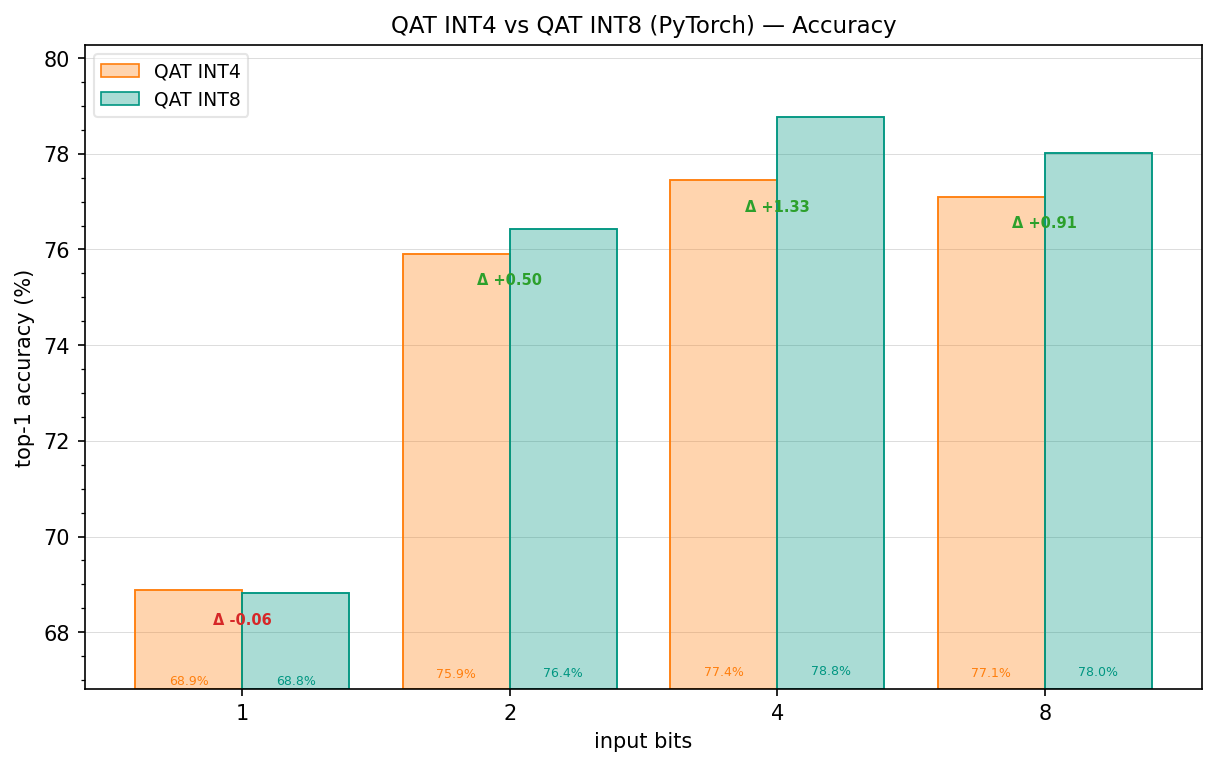

In [18]:
qat_i4 = table_qat[table_qat["precision"] == "qat_int4"].sort_values("input_bits").reset_index(drop=True)
qat_i8 = table_qat[table_qat["precision"] == "qat_int8"].sort_values("input_bits").reset_index(drop=True)

groups = [
    ("QAT INT4", qat_i4, QAT_PALETTE["qat_int4"]),
    ("QAT INT8", qat_i8, QAT_PALETTE["qat_int8"]),
]

bits_list = sorted(qat_i4["input_bits"].astype(int).unique())
x_pos = np.arange(len(bits_list))
n_grp = len(groups)
width = 0.8 / n_grp

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

all_vals = pd.concat([g[1]["top1_mean"] for g in groups])
y_bottom = all_vals.min() - 2
y_top = all_vals.max() + 1.5
ax.set_ylim(y_bottom, y_top)

for gi, (label, grp, color) in enumerate(groups):
    offset = (gi - (n_grp - 1) / 2) * width
    for i, (_, row) in enumerate(grp.iterrows()):
        ax.bar(x_pos[i] + offset, row["top1_mean"] - y_bottom, width,
               bottom=y_bottom,
               color=color + "55", edgecolor=color, linewidth=0.9, zorder=2)
        ax.text(x_pos[i] + offset, y_bottom + (row["top1_mean"] - y_bottom) * 0.02,
                f"{row['top1_mean']:.1f}%", ha="center", va="bottom",
                fontsize=6, color=color, zorder=3)

for i in range(len(bits_list)):
    i4_val = qat_i4.iloc[i]["top1_mean"]
    i8_val = qat_i8.iloc[i]["top1_mean"]
    delta = i8_val - i4_val
    sign = "+" if delta >= 0 else ""
    delta_color = "#D62728" if delta < 0 else "#2ca02c"
    ax.text(x_pos[i], min(i4_val, i8_val) - 0.4,
            f"Δ {sign}{delta:.2f}",
            ha="center", va="top", fontsize=7, fontweight="bold",
            color=delta_color, zorder=4)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits_list])
ax.set_xlabel("input bits")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("QAT INT4 vs QAT INT8 (PyTorch) — Accuracy", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c,
                  linewidth=0.8, label=lbl)
    for lbl, _, c in groups
]
ax.legend(handles=handles, fontsize=9, framealpha=0.5, loc="upper left")

plt.show()

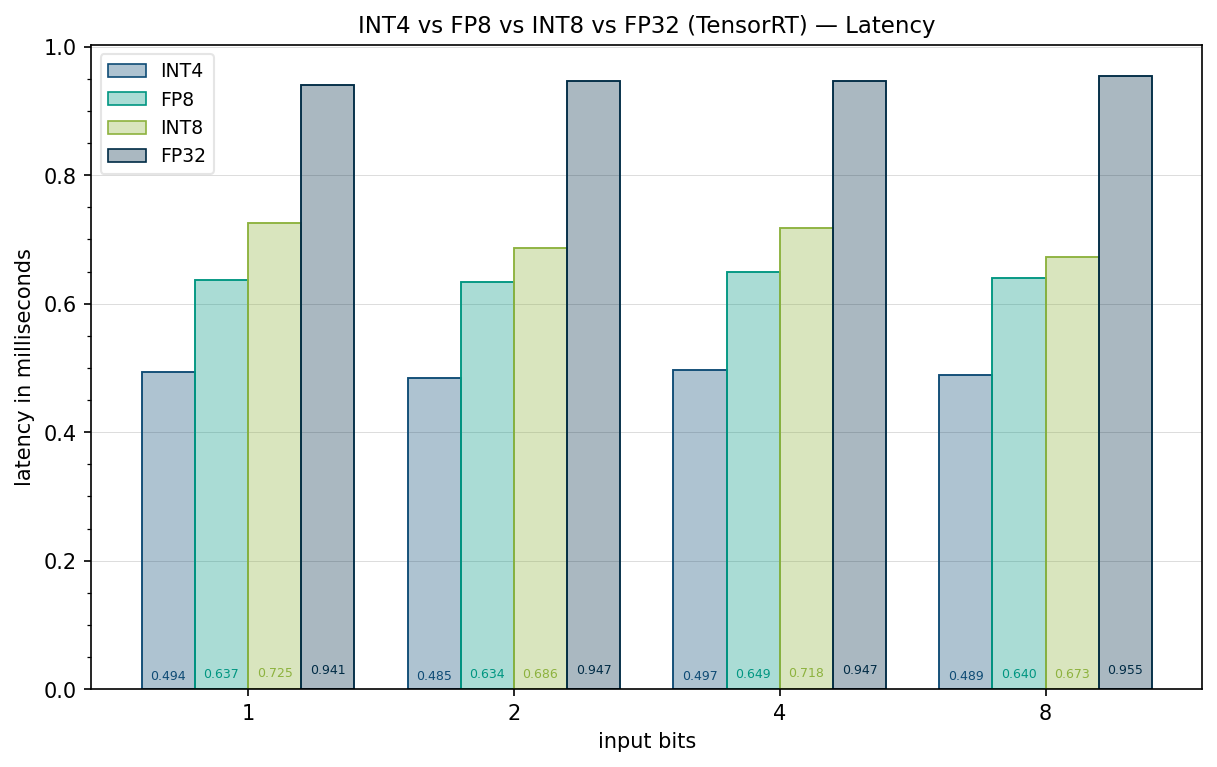

In [19]:
prec_order = ["int4", "fp8", "int8", "fp32"]
trt_groups = []
for prec in prec_order:
    grp = table_results[
        (table_results["backend"] == "tensorrt") & (table_results["precision"] == prec)
    ].sort_values("input_bits").reset_index(drop=True)
    trt_groups.append((prec.upper(), grp, PREC_PALETTE[prec]))

bits_list = sorted(trt_groups[0][1]["input_bits"].astype(int).unique())
x_pos = np.arange(len(bits_list))
n_grp = len(trt_groups)
width = 0.8 / n_grp

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for gi, (label, grp, color) in enumerate(trt_groups):
    offset = (gi - (n_grp - 1) / 2) * width
    for i, (_, row) in enumerate(grp.iterrows()):
        ax.bar(x_pos[i] + offset, row["infer_ms_mean"], width,
               color=color + "55", edgecolor=color, linewidth=0.9, zorder=2)
        ax.text(x_pos[i] + offset, row["infer_ms_mean"] * 0.02,
                f"{row['infer_ms_mean']:.3f}", ha="center", va="bottom",
                fontsize=6, color=color, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits_list])
ax.set_xlabel("input bits")
ax.set_ylabel("latency in milliseconds")
ax.set_title("INT4 vs FP8 vs INT8 vs FP32 (TensorRT) — Latency", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c,
                  linewidth=0.8, label=lbl)
    for lbl, _, c in trt_groups
]
ax.legend(handles=handles, fontsize=9, framealpha=0.5, loc="upper left")

plt.show()

## Accuracy Matrix — all configurations

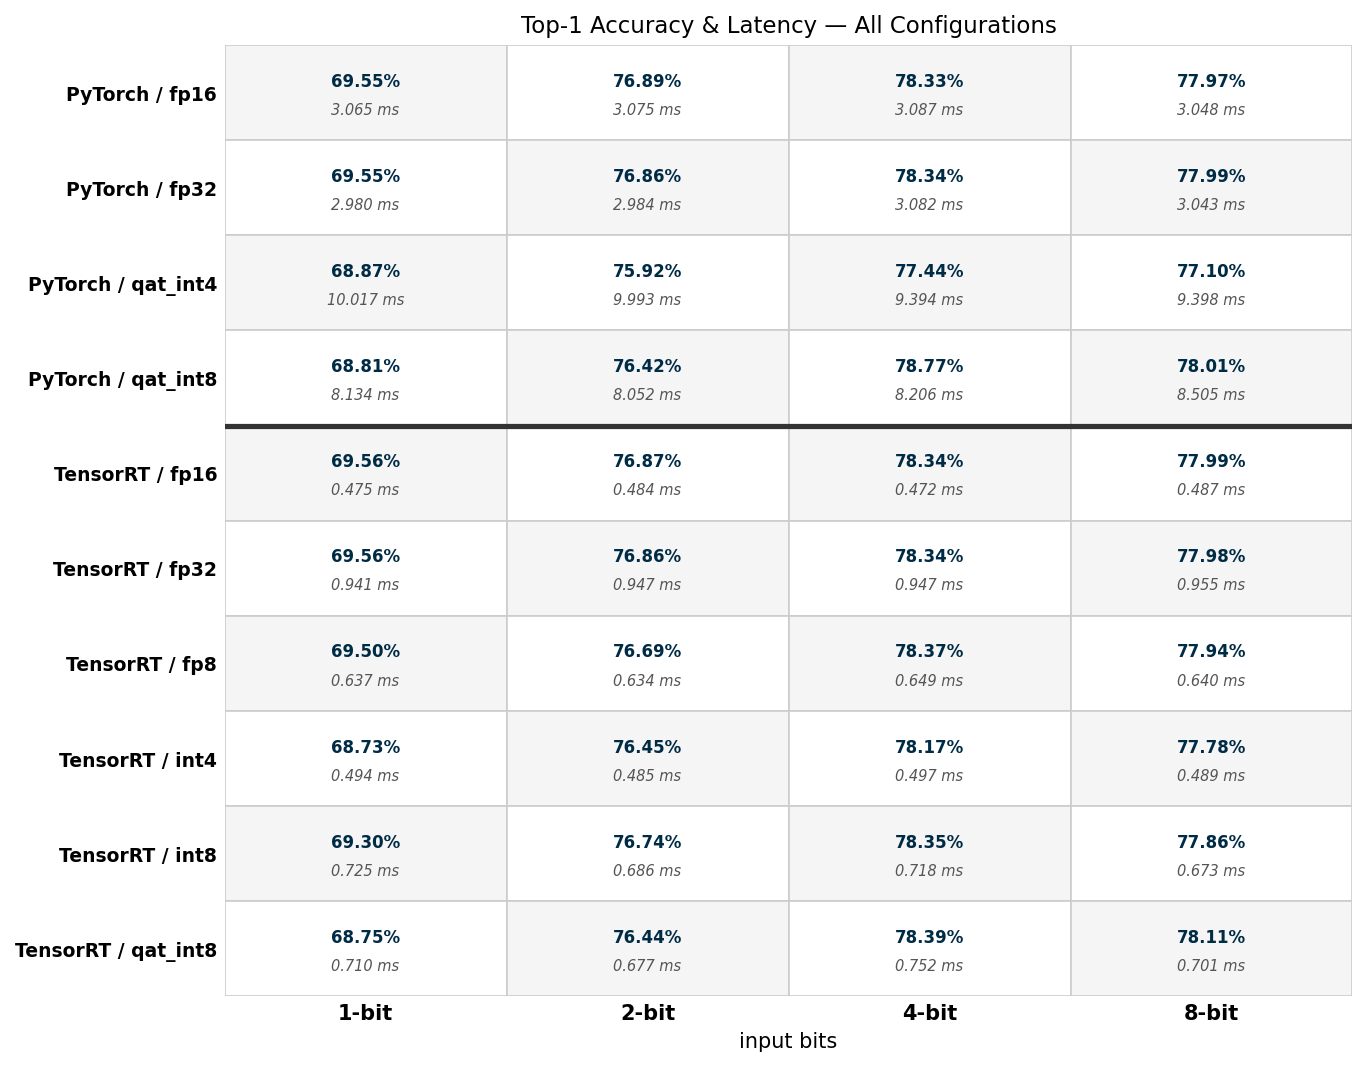

In [20]:
from matplotlib.patches import Rectangle

bit_cols = [1, 2, 4, 8]

pt_precs = ["fp16", "fp32", "qat_int4", "qat_int8"]
trt_precs = ["fp16", "fp32", "fp8", "int4", "int8", "qat_int8"]

row_labels = []
acc_vals = []
lat_vals = []

for prec in pt_precs:
    row_labels.append(f"PyTorch / {prec}")
    acc_row, lat_row = [], []
    for b in bit_cols:
        match = combined[
            (combined["backend"] == "pytorch") & (combined["precision"] == prec) & (combined["input_bits"] == b)
        ]
        if len(match):
            acc_row.append(match["top1_mean"].values[0])
            lat_row.append(match["infer_ms_mean"].values[0])
        else:
            acc_row.append(np.nan)
            lat_row.append(np.nan)
    acc_vals.append(acc_row)
    lat_vals.append(lat_row)

for prec in trt_precs:
    row_labels.append(f"TensorRT / {prec}")
    acc_row, lat_row = [], []
    for b in bit_cols:
        match = combined[
            (combined["backend"] == "tensorrt") & (combined["precision"] == prec) & (combined["input_bits"] == b)
        ]
        if len(match):
            acc_row.append(match["top1_mean"].values[0])
            lat_row.append(match["infer_ms_mean"].values[0])
        else:
            acc_row.append(np.nan)
            lat_row.append(np.nan)
    acc_vals.append(acc_row)
    lat_vals.append(lat_row)

acc_matrix = np.array(acc_vals)
lat_matrix = np.array(lat_vals)

n_rows = len(row_labels)
n_cols = len(bit_cols)

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)

for i in range(n_rows):
    for j in range(n_cols):
        acc = acc_matrix[i, j]
        lat = lat_matrix[i, j]

        bg = "#f5f5f5" if (i + j) % 2 == 0 else "#ffffff"
        rect = Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=bg, edgecolor="#cccccc", linewidth=0.8)
        ax.add_patch(rect)

        if np.isnan(acc):
            continue

        ax.text(j, i - 0.12, f"{acc:.2f}%", ha="center", va="center",
                fontsize=8, fontweight="bold", color="#002B45")
        ax.text(j, i + 0.18, f"{lat:.3f} ms", ha="center", va="center",
                fontsize=7, color="#555555", fontstyle="italic")

ax.axhline(y=len(pt_precs) - 0.5, color="#333333", linewidth=2.5)

ax.set_xticks(np.arange(n_cols))
ax.set_xticklabels([f"{b}-bit" for b in bit_cols], fontweight="bold")
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(row_labels, fontsize=9, fontweight="bold")
ax.set_xlabel("input bits")
ax.set_title("Top-1 Accuracy & Latency — All Configurations", fontsize=11)

ax.set_aspect("auto")
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()